#Team Members - AI NEXUS

1. Tanay Tammineni, S02065959, graduate

2. Vidya rani vallala, S02066899, graduate

3. Supriya Bollareddy, S02050758, graduate

4. Lahari Maddukuri, S02050755, graduate

5. Narendra Dhulipalla, S02049657, graduate

6. Gayatri Vattuluri, S02059506, graduate




# Maze Search









Reference : Textbook online repository files (search4e.ipynb) in
aima-python, or similar files in other folders, such as aima-java.

#Problem:

In order to expedite the process of creating specialized problem domains, we begin by establishing an abstract class that serves as the foundation for specifying particular problems. This abstract class provides the foundation for creating several subclasses that are suited to different problem domains. When algorithms require heuristic evaluation functions, the problem class is assigned a default h function that is initially set to zero. The following subclasses are still free to define their own default h function, which takes into account the particularities of their domain. Furthermore, its architecture promotes flexibility and extensibility, allowing for the easy incorporation of innovative approaches to problem-solving and heuristic evaluation techniques. As a result, the abstract class acts as a versatile framework that encourages modular design and effective problem-solving techniques in a variety of contexts.


The `Problem` class defines an abstract framework for formal problem representation, offering methods for actions, results, and heuristic evaluation. Subclasses must override these methods to define specific problem domains and associated problem-solving strategies.


In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
import random
import heapq
import math
import sys
from collections import defaultdict, deque, Counter
from itertools import combinations


class Problem(object):
    """The abstract class for a formal problem. A new domain subclasses this,
    overriding `actions` and `results`, and perhaps other methods.
    The default heuristic is 0 and the default action cost is 1 for all states.
    When yiou create an instance of a subclass, specify `initial`, and `goal` states
    (or give an `is_goal` method) and perhaps other keyword args for the subclass."""

    def __init__(self, initial=None, goal=None, **kwds):
        self.__dict__.update(initial=initial, goal=goal, **kwds)

    def actions(self, state):        raise NotImplementedError
    def result(self, state, action): raise NotImplementedError
    def is_goal(self, state):        return state == self.goal
    def action_cost(self, s, a, s1): return 1
    def h(self, node):               return 0

    def __str__(self):
        return '{}({!r}, {!r})'.format(
            type(self).__name__, self.initial, self.goal)


#Node

A node in a search tree that is utilized by different search methods is represented by the `Node` class. It contains data like the node's depth in the search tree, the current state, the parent node, the action performed from the parent node to reach the current state, and the cumulative path cost.

- {state}: Describes the problem's existing situation.
- {parent}: Indicates the parent node that is used to access the current node.
- {action}: Indicates the step the parent node took to get to the current state.
- {path_cost}: Indicates the total amount of money spent from the starting point to the present.
- {depth}: Shows how far down the node is in the search tree, or how many steps were needed to get to the current state fromthe initial state.

In [35]:
class Node:
    "A Node in a search tree."
    def __init__(self, state, parent=None, action=None, path_cost=0,depth=0):
        self.__dict__.update(state=state, parent=parent, action=action, path_cost=path_cost,depth=depth)

    def __repr__(self): return '<{}>'.format(self.state)
    def __len__(self): return 0 if self.parent is None else (1 + len(self.parent))
    def __lt__(self, other): return self.path_cost < other.path_cost


failure = Node('failure', path_cost=math.inf)
cutoff  = Node('cutoff',  path_cost=math.inf)


def expand(problem, node):
    "Expand a node, generating the children nodes."
    s = node.state
    for action in problem.actions(s):
        s1 = problem.result(s, action)
        cost = node.path_cost + problem.action_cost(s, action, s1)
        yield Node(s1, node, action, cost,node.depth + 1)


def path_actions(node):
    "The sequence of actions to get to this node."
    if node.parent is None:
        return []
    return path_actions(node.parent) + [node.action]


def path_states(node):
    "The sequence of states to get to this node."
    if node in (cutoff, failure, None):
        return []
    return path_states(node.parent) + [node.state]

#QUEUES


Search algorithms provide queues such as `PriorityQueue}, which retains things together while continuously eliminating the item with the lowest f(item) score, and `deque}, which follows a last-in-first-out (LIFO) order. These data structures control the sequence in which nodes are examined during the search process, enabling various search strategies like depth-first search, breadth-first search, and A* search. Furthermore, the search algorithm's efficacy and efficiency in locating the best solutions are influenced by the data structure selection.


In [36]:

LIFOQueue = list

#PriorityQueue

By giving each of its constituents a distinct priority number, a priority queue essentially creates several queue types. It performs effective heap-related actions by using the `heapq` module, making sure that things with higher priority numbers are handled first. This makes it possible to quickly construct a variety of algorithms, where the exploration order of nodes is determined by their priority, such as Dijkstra's algorithm and A* search. Priority Queues are an essential part of many optimization and search methods because heap data structures allow for quick element insertion and retrieval.


In [37]:
import heapq

class PriorityQueue:
    """A queue in which the item with minimum f(item) is always popped first."""

    def __init__(self, items=(), key=lambda x: x):
        self.key = key
        self.items = []
        for item in items:
            self.add(item)

    def add(self, item):
        """Add item to the queuez."""
        pair = (self.key(item), item)
        heapq.heappush(self.items, pair)

    def pop(self):
        """Pop and return the item with min f(item) value."""
        return heapq.heappop(self.items)[1]

    def top(self): return self.items[0][1]

    def __len__(self): return len(self.items)


#Plotting function

A maze expressed as a 2D array can be shown using the `maze_plot` function. Matplotlib is used to generate a graphical depiction of the maze. The program iterates through every maze cell, designating particular characters—for example, '%' for walls, 'P' for the player's position, and '.' for the objective. The plot is then expanded to include the corresponding shapes: green circles represent the player's position, blue rectangles represent the walls, and red dotted circles represent the objective. It also modifies the plot's boundaries to match the maze's dimensions and maintains an equal aspect ratio. Lastly, to indicate the borders of the maze, it paints a blue dotted line around the outside. The plot that results offers a graphic representation of the maze layout, helping users understand its structure and aiding in pathfinding or exploration algorithms.

In [38]:
import matplotlib.pyplot as plt

def maze_plot(maze):
    fig, ax = plt.subplots()

    for i in range(len(maze)):
        for j in range(len(maze[i])):
            if maze[i][j] == '%':
                ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='blue'))
            elif maze[i][j] == 'P':
                ax.add_patch(plt.Circle((j + 0.5, i + 0.5), 0.25, facecolor='green'))
            elif maze[i][j] == '.':
                ax.add_patch(plt.Circle((j + 0.5, i + 0.5), 0.25, facecolor='red', linestyle='dotted'))

    ax.set_xlim(0, len(maze[0]))
    ax.set_ylim(len(maze), 0)
    ax.set_aspect('equal')

    ax.plot([0, 0, len(maze[0]), len(maze[0]), 0],
            [0, len(maze), len(maze), 0, 0],
            color='blue', linestyle='dotted')

    plt.show()


In [39]:
class SearchResult:
    def __init__(self, node, max_fringe_size):
        self.node = node
        self.max_fringe_size = max_fringe_size

#DFS algorithm

One popular method for navigating and exploring labyrinth data structures is depth-first search (DFS). It works by following a path as far down as it can go before turning around. In other words, it follows one path until it comes to a stop, at which point it goes back to the most recent intersection to investigate possibilities that haven't yet been considered. Until the target is located or the entire maze has been thoroughly investigated, this iterative procedure is carried out. DFS is an essential tool for pathfinding and problem-solving in a variety of disciplines and is crucial to both computer science and graph theory.


In [40]:
def dfs(problem):
    node = Node(problem.initial)
    if problem.is_goal(problem.initial):
        return SearchResult(node, 0)
    frontier = LIFOQueue([node])
    reached = {problem.initial}
    max_fringe_size = 0
    while frontier:
        node = frontier.pop()
        max_fringe_size = max(max_fringe_size, len(frontier))
        for child in expand(problem, node):
            s = child.state
            if problem.is_goal(s):
                return SearchResult(child, max_fringe_size)
            if s not in reached:
                reached.add(s)
                frontier.append(child)

    return SearchResult(failure, max_fringe_size)



#A* algorithm

The A* algorithm, also called "A-star," is a sophisticated method for pathfinding and graph traversal that works especially well for figuring out the shortest route between two nodes in a weighted graph. This algorithm combines the ideas of Dijkstra's algorithm—which finds the shortest path without using any specific heuristics—with the concepts of heuristic search, which uses well-informed estimations or heuristics to direct the exploration. By combining these components, A* quickly finds the best path while taking into account the estimated distance to the objective node as well as the cost spent. It does this by striking a balance between exploration and exploitation. Because of its hybrid character, A* is an algorithm that is widely used in a variety of industries and makes pathfinding and optimization tasks in a wide range of applications efficient.


In [41]:
def best_first_search(problem, f):
    "Search nodes with minimum f(node) value first."
    node = Node(problem.initial)
    if problem.is_goal(problem.initial):
        return SearchResult(node, 0)
    frontier = PriorityQueue([node], key=f)
    reached = {problem.initial: node}
    max_fringe_size = 0
    while frontier:
        max_fringe_size = max(max_fringe_size, len(frontier))
        node = frontier.pop()
        if problem.is_goal(node.state):
            return SearchResult(node, max_fringe_size)
        for child in expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                frontier.add(child)
    return SearchResult(failure, max_fringe_size)


In [42]:

import math


def g(n): return n.path_cost

def astar_search(problem):
    """Search nodes with minimum f(n) = g(n) + h(n), using Manhattan distance as the heuristic."""
    def h(node):
        """Manhattan distance from the current position to the goal as the heuristic function."""
        current_state = node.state
        goal_state = problem.goal
        distance = abs(current_state[0] - goal_state[0]) + abs(current_state[1] - goal_state[1])
        return distance

    return best_first_search(problem, f=lambda n: g(n) + h(n))



#Maze Problem

Finding a way from a starting point to a predetermined destination through a labyrinth is a challenge that is captured by the `Maze_Problem class. Its methods are overridden, expressly to make them suitable for maze navigation, and it derives from the {Problem} class. The beginning point, the objective position, and the maze itself are the three parameters passed to the class constructor. Using the cardinal directions (north, south, east, and west) as a guide, the `actions` method finds all possible paths from a given state inside the maze, avoiding the walls indicated by '%'. To make it easier to navigate the maze, the `result` method calculates the state that is reached after doing a specific action from a specific state. Further, a textual representation of the maze is made possible using the `__str__ method. In general, the class `Maze_Problem` provides a framework for solving maze navigation problems, enabling the exploration and navigation of complex maze structures in a systematic manner using various search algorithms.

In [43]:
class Maze_Problem(Problem):
    """The problem of searching a path through a maze from start to goal."""

    def __init__(self, maze, start, goal):
        self.maze = maze
        Problem.__init__(self, initial=start, goal=goal)

    def actions(self, state):
        "Return the actions that can be executed in the given state."
        row, col = state
        actions = []
        if row > 0 and self.maze[row-1][col] != '%': actions.append('N')
        if row < len(self.maze)-1 and self.maze[row+1][col] != '%': actions.append('S')
        if col > 0 and self.maze[row][col-1] != '%': actions.append('W')
        if col < len(self.maze[row])-1 and self.maze[row][col+1] != '%': actions.append('E')
        return actions

    def result(self, state, action):
        "Return the state that results from executing the given action in the given state."
        row, col = state
        if action == 'N': return (row-1, col)
        if action == 'S': return (row+1, col)
        if action == 'W': return (row, col-1)
        if action == 'E': return (row, col+1)
        assert False, 'Not a valid action: {}'.format(action)

    def __str__(self):
        return '\n'.join([''.join(row) for row in self.maze])





#Report


A summary of statistics for every searcher method used to solve a given set of issues is what the `report` function is intended to offer. It writes out the name of each searcher after iterating over all of the ones in the `searchers` list. It generates a `CountCalls` object for each problem in the `problems` list to monitor attribute access counts, and it assigns the problem solving task to the corresponding searcher algorithm. During the search process, it updates counters with pertinent data like the quantity of actions executed, the cost of the path, and the size of the fringe. It publishes out specific counts for each problem along with the path to solution if the {verbose` argument is set to `True}. It reports the highest tree depth searched across all problems after processing them all problems for each searcher algorithm. A helper function called `report_counts` is used within `report` to produce one line of the counts report, which includes information about the solution path, number of expanding nodes, and maximum size of the fringe during the search. The efficiency of various search algorithms may be thoroughly analyzed and compared across numerous problem instances thanks to this modular design.




In [44]:

class CountCalls:
    """Delegate all attribute gets to the object, and count them in ._counts"""
    def __init__(self, obj):
        self._object = obj
        self._counts = Counter()

    def __getattr__(self, attr):
        "Delegate to the original object, after incrementing a counter."
        self._counts[attr] += 1
        return getattr(self._object, attr)

def report(searchers, problems,solution_path, verbose=True):
    """Show summary statistics for each searcher (and on each problem unless verbose is false)."""
    for searcher in searchers:
        print(searcher.__name__ + ':')
        total_counts = Counter()
        max_depth = 0
        for p in problems:
            prob   = CountCalls(p)
            soln   = searcher(prob)
            counts = prob._counts;
            max_depth = max(max_depth, soln.node.depth)
            if soln.node == failure:
                counts.update(actions=0, cost=0, fringe_size=soln.max_fringe_size)
            else:
                counts.update(actions=len(path_states(soln.node)), cost=soln.node.path_cost, fringe_size=soln.max_fringe_size)
            total_counts += counts
            if verbose: report_counts(counts, solution_path )
        #report_counts(total_counts, solution_path)
        print(f"Maximum tree depth searched: {max_depth}")


def report_counts(counts, name):
    """Print one line of the counts report."""
    #print("Path cost is",counts['cost'],"\n")
    print("Solution path is ",name,"\n")
    print("Number of nodes expanded",counts['result'],"\n")
    print("Maximum size of finge",counts['fringe_size'],"\n")




#sample maze file.lay

**Depth-First-Search for small maze**

Start Goal
(29, 1) (1, 79)


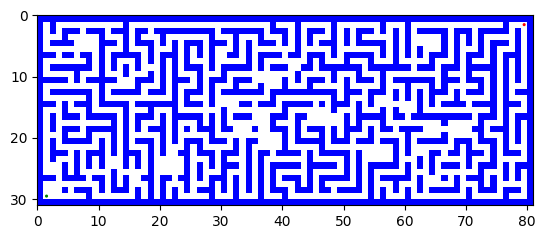

 
 path to reach from  (29, 1) to  (1, 79)  is
 
[(29, 1), (29, 2), (29, 3), (29, 4), (29, 5), (28, 5), (27, 5), (27, 6), (27, 7), (27, 8), (27, 9), (28, 9), (29, 9), (29, 10), (29, 11), (29, 12), (29, 13), (29, 14), (29, 15), (28, 15), (27, 15), (27, 16), (26, 16), (25, 16), (25, 17), (24, 17), (23, 17), (22, 17), (21, 17), (21, 16), (21, 15), (20, 15), (19, 15), (19, 16), (19, 17), (19, 18), (19, 19), (20, 19), (21, 19), (22, 19), (23, 19), (23, 20), (23, 21), (23, 22), (23, 23), (24, 23), (25, 23), (25, 22), (26, 22), (27, 22), (27, 23), (28, 23), (29, 23), (29, 24), (29, 25), (28, 25), (27, 25), (27, 26), (27, 27), (26, 27), (25, 27), (25, 28), (25, 29), (24, 29), (23, 29), (22, 29), (21, 29), (21, 30), (21, 31), (20, 31), (19, 31), (19, 32), (19, 33), (19, 34), (19, 35), (19, 36), (19, 37), (19, 38), (19, 39), (20, 39), (21, 39), (21, 38), (22, 38), (23, 38), (23, 39), (23, 40), (23, 41), (23, 42), (23, 43), (24, 43), (25, 43), (25, 42), (25, 41), (25, 40), (25, 39), (26, 39), (27

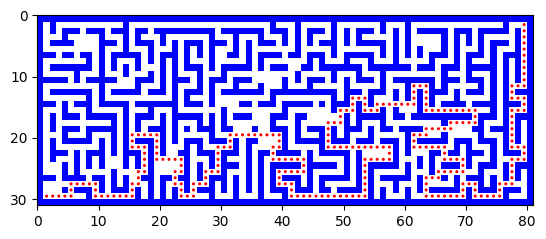

In [69]:

with open("/content/sample maze file.lay", "r") as sampleMazefile:
    maze=list(sampleMazefile)


start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print("Start","Goal")
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)

  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  print(' ')
  print(' ')
  maze_plot(li)

#smallMaze.lay

**Depth-First-Search for small maze**

Start Goal
(3, 11) (8, 1)


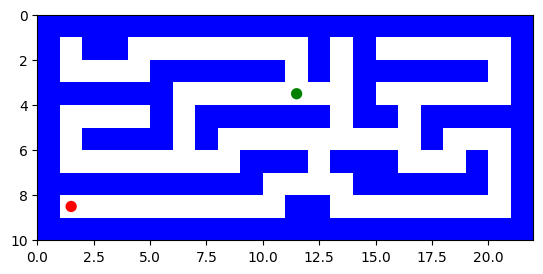

 
 path to reach from  (3, 11) to  (8, 1)  is
 
[(3, 11), (3, 12), (3, 13), (4, 13), (5, 13), (5, 14), (5, 15), (5, 16), (6, 16), (6, 17), (6, 18), (5, 18), (5, 19), (5, 20), (6, 20), (7, 20), (8, 20), (8, 19), (8, 18), (8, 17), (8, 16), (8, 15), (8, 14), (8, 13), (7, 13), (7, 12), (7, 11), (7, 10), (8, 10), (8, 9), (8, 8), (8, 7), (8, 6), (8, 5), (8, 4), (8, 3), (8, 2), (8, 1)]
 
%%%%%%%%%%%%%%%%%%%%%%
% %%        % %      %
%    %%%%%% % %%%%%% %
%%%%%%     ...%      %
%    % %%%%%%.%% %%%%%
% %%%% %     ....%...%
%        %%% %%%...%.%
%%%%%%%%%%....%%%%%%.%
%..........%%........%
%%%%%%%%%%%%%%%%%%%%%%
 
 


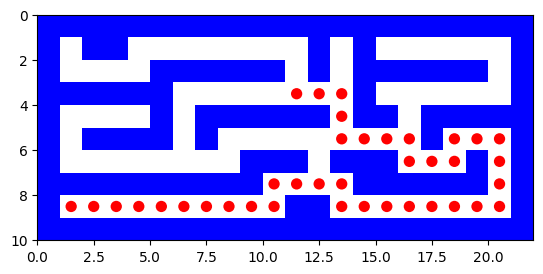

In [45]:

with open("/content/smallMaze.lay", "r") as smallMazefile:
    maze=list(smallMazefile)


start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print("Start","Goal")
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)

  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  print(' ')
  print(' ')
  maze_plot(li)

#Report for Depth-First-Search for small Maze

In [46]:
print("Report for Depth-First-Search for small Maze")
print(' ')

report([dfs], [problem],dfs_solution_path)

Report for Depth-First-Search for small Maze
 
dfs:
Solution path is  [(3, 11), (3, 12), (3, 13), (4, 13), (5, 13), (5, 14), (5, 15), (5, 16), (6, 16), (6, 17), (6, 18), (5, 18), (5, 19), (5, 20), (6, 20), (7, 20), (8, 20), (8, 19), (8, 18), (8, 17), (8, 16), (8, 15), (8, 14), (8, 13), (7, 13), (7, 12), (7, 11), (7, 10), (8, 10), (8, 9), (8, 8), (8, 7), (8, 6), (8, 5), (8, 4), (8, 3), (8, 2), (8, 1)] 

Number of nodes expanded 78 

Maximum size of finge 6 

Maximum tree depth searched: 37


#A* search for small Maze

(3, 11) (8, 1)


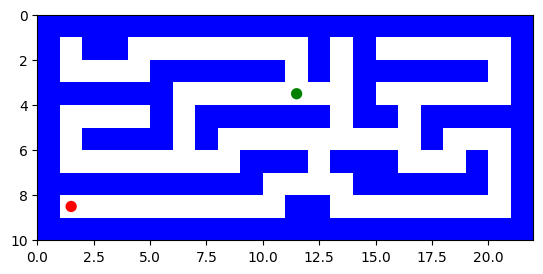

 
 path to reach from  (3, 11) to  (8, 1)  is
 
[(3, 11), (3, 12), (3, 13), (4, 13), (5, 13), (5, 12), (6, 12), (7, 12), (7, 11), (7, 10), (8, 10), (8, 9), (8, 8), (8, 7), (8, 6), (8, 5), (8, 4), (8, 3), (8, 2), (8, 1)]
 
%%%%%%%%%%%%%%%%%%%%%%
% %%        % %      %
%    %%%%%% % %%%%%% %
%%%%%%     ...%      %
%    % %%%%%%.%% %%%%%
% %%%% %    ..   %   %
%        %%%.%%%   % %
%%%%%%%%%%... %%%%%% %
%..........%%        %
%%%%%%%%%%%%%%%%%%%%%%


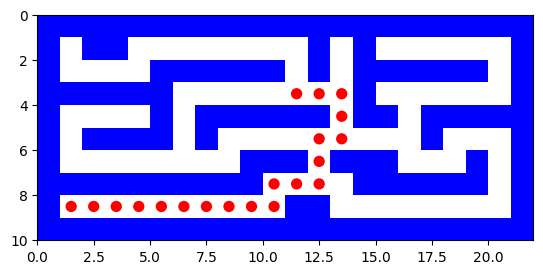

In [48]:

with open("/content/smallMaze.lay", "r") as smallMazefile:
    maze=list(smallMazefile)



start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)


#Report for A* Search for small Maze

In [49]:
print("Report for A* Search for small Maze")
print(' ')

report([astar_search], [problem],astar_solution_path)

Report for A* Search for small Maze
 
astar_search:
Solution path is  [(3, 11), (3, 12), (3, 13), (4, 13), (5, 13), (5, 12), (6, 12), (7, 12), (7, 11), (7, 10), (8, 10), (8, 9), (8, 8), (8, 7), (8, 6), (8, 5), (8, 4), (8, 3), (8, 2), (8, 1)] 

Number of nodes expanded 112 

Maximum size of finge 8 

Maximum tree depth searched: 19


#bigMaze.lay

**Depth-First-Search for big maze**

(35, 35) (35, 1)


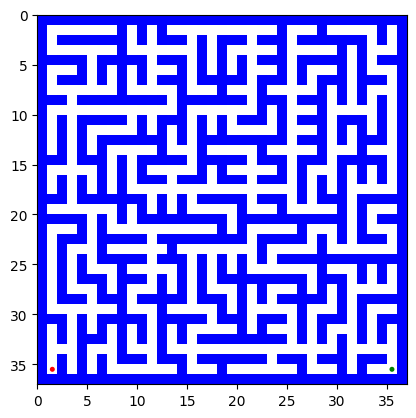

 
 path to reach from  (35, 35) to  (35, 1)  is
 
[(35, 35), (34, 35), (33, 35), (33, 34), (33, 33), (33, 32), (33, 31), (32, 31), (31, 31), (31, 30), (31, 29), (32, 29), (33, 29), (33, 28), (33, 27), (33, 26), (33, 25), (33, 24), (33, 23), (33, 22), (33, 21), (33, 20), (33, 19), (33, 18), (33, 17), (33, 16), (33, 15), (32, 15), (31, 15), (31, 16), (31, 17), (30, 17), (29, 17), (29, 16), (29, 15), (28, 15), (27, 15), (26, 15), (25, 15), (24, 15), (23, 15), (23, 16), (23, 17), (23, 18), (23, 19), (23, 20), (23, 21), (24, 21), (25, 21), (25, 22), (25, 23), (24, 23), (23, 23), (23, 24), (23, 25), (23, 26), (23, 27), (22, 27), (21, 27), (21, 28), (21, 29), (22, 29), (23, 29), (23, 30), (23, 31), (22, 31), (21, 31), (20, 31), (19, 31), (18, 31), (17, 31), (17, 32), (17, 33), (17, 34), (17, 35), (16, 35), (15, 35), (14, 35), (13, 35), (12, 35), (11, 35), (10, 35), (9, 35), (8, 35), (7, 35), (7, 34), (7, 33), (8, 33), (9, 33), (9, 32), (9, 31), (9, 30), (9, 29), (10, 29), (11, 29), (12, 29), 

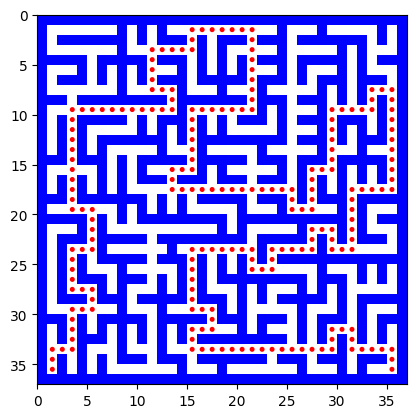

In [50]:


with open("/content/bigMaze.lay", "r") as bigMazefile:
    maze=list(bigMazefile)


start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  print(' ')
  print(' ')
  maze_plot(li)



#Report for Depth-First-Search for big Maze

In [51]:

print("Report for Depth-First-Search for big Maze")
print(' ')

report([dfs], [problem],dfs_solution_path)


Report for Depth-First-Search for big Maze
 
dfs:
Solution path is  [(35, 35), (34, 35), (33, 35), (33, 34), (33, 33), (33, 32), (33, 31), (32, 31), (31, 31), (31, 30), (31, 29), (32, 29), (33, 29), (33, 28), (33, 27), (33, 26), (33, 25), (33, 24), (33, 23), (33, 22), (33, 21), (33, 20), (33, 19), (33, 18), (33, 17), (33, 16), (33, 15), (32, 15), (31, 15), (31, 16), (31, 17), (30, 17), (29, 17), (29, 16), (29, 15), (28, 15), (27, 15), (26, 15), (25, 15), (24, 15), (23, 15), (23, 16), (23, 17), (23, 18), (23, 19), (23, 20), (23, 21), (24, 21), (25, 21), (25, 22), (25, 23), (24, 23), (23, 23), (23, 24), (23, 25), (23, 26), (23, 27), (22, 27), (21, 27), (21, 28), (21, 29), (22, 29), (23, 29), (23, 30), (23, 31), (22, 31), (21, 31), (20, 31), (19, 31), (18, 31), (17, 31), (17, 32), (17, 33), (17, 34), (17, 35), (16, 35), (15, 35), (14, 35), (13, 35), (12, 35), (11, 35), (10, 35), (9, 35), (8, 35), (7, 35), (7, 34), (7, 33), (8, 33), (9, 33), (9, 32), (9, 31), (9, 30), (9, 29), (10, 29), (1

#A* search for big Maze

(35, 35) (35, 1)


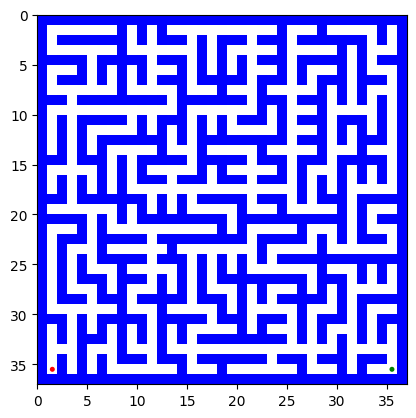

 
 path to reach from  (35, 35) to  (35, 1)  is
 
[(35, 35), (34, 35), (33, 35), (33, 34), (33, 33), (33, 32), (33, 31), (32, 31), (31, 31), (31, 30), (31, 29), (32, 29), (33, 29), (33, 28), (33, 27), (33, 26), (33, 25), (33, 24), (33, 23), (33, 22), (33, 21), (33, 20), (33, 19), (33, 18), (33, 17), (33, 16), (33, 15), (32, 15), (31, 15), (31, 16), (31, 17), (30, 17), (29, 17), (29, 16), (29, 15), (28, 15), (27, 15), (26, 15), (25, 15), (24, 15), (23, 15), (23, 16), (23, 17), (23, 18), (23, 19), (23, 20), (23, 21), (24, 21), (25, 21), (25, 22), (25, 23), (24, 23), (23, 23), (23, 24), (23, 25), (23, 26), (23, 27), (22, 27), (21, 27), (21, 28), (21, 29), (22, 29), (23, 29), (23, 30), (23, 31), (22, 31), (21, 31), (20, 31), (19, 31), (18, 31), (17, 31), (17, 32), (17, 33), (17, 34), (17, 35), (16, 35), (15, 35), (14, 35), (13, 35), (12, 35), (11, 35), (10, 35), (9, 35), (8, 35), (7, 35), (7, 34), (7, 33), (8, 33), (9, 33), (9, 32), (9, 31), (9, 30), (9, 29), (10, 29), (11, 29), (12, 29), 

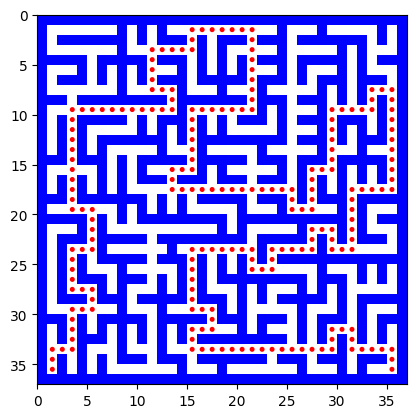

In [52]:

with open("/content/bigMaze.lay", "r") as bigMazefile:
    maze=list(bigMazefile)



start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)

  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)



#Report for A* Search for big Maze

In [53]:
print("Report for A* Search for big Maze")
print(' ')

report([astar_search], [problem],astar_solution_path)

Report for A* Search for big Maze
 
astar_search:
Solution path is  [(35, 35), (34, 35), (33, 35), (33, 34), (33, 33), (33, 32), (33, 31), (32, 31), (31, 31), (31, 30), (31, 29), (32, 29), (33, 29), (33, 28), (33, 27), (33, 26), (33, 25), (33, 24), (33, 23), (33, 22), (33, 21), (33, 20), (33, 19), (33, 18), (33, 17), (33, 16), (33, 15), (32, 15), (31, 15), (31, 16), (31, 17), (30, 17), (29, 17), (29, 16), (29, 15), (28, 15), (27, 15), (26, 15), (25, 15), (24, 15), (23, 15), (23, 16), (23, 17), (23, 18), (23, 19), (23, 20), (23, 21), (24, 21), (25, 21), (25, 22), (25, 23), (24, 23), (23, 23), (23, 24), (23, 25), (23, 26), (23, 27), (22, 27), (21, 27), (21, 28), (21, 29), (22, 29), (23, 29), (23, 30), (23, 31), (22, 31), (21, 31), (20, 31), (19, 31), (18, 31), (17, 31), (17, 32), (17, 33), (17, 34), (17, 35), (16, 35), (15, 35), (14, 35), (13, 35), (12, 35), (11, 35), (10, 35), (9, 35), (8, 35), (7, 35), (7, 34), (7, 33), (8, 33), (9, 33), (9, 32), (9, 31), (9, 30), (9, 29), (10, 29), (1

#mediumMaze.lay

**Depth-First-Search for medium maze**

(1, 34) (16, 1)


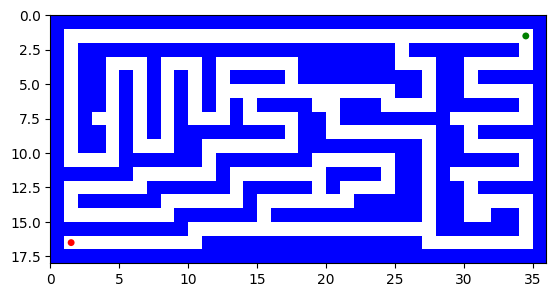

 
 path to reach from  (1, 34) to  (16, 1)  is
 
[(1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (1, 24), (1, 23), (1, 22), (1, 21), (1, 20), (1, 19), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (10, 2), (10, 3), (10, 4), (9, 4), (8, 4), (7, 4), (6, 4), (5, 4), (4, 4), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (9, 7), (9, 8), (8, 8), (7, 8), (6, 8), (5, 8), (4, 8), (3, 8), (3, 9), (3, 10), (4, 10), (5, 10), (6, 10), (7, 10), (7, 11), (7, 12), (6, 12), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 19), (5, 20), (6, 20), (7, 20), (8, 20), (8, 21), (8, 22), (8, 23), (8, 24), (8, 25), (8, 26), (8, 27), (9, 27), (10, 27), (11, 27), (12, 27), (13, 27), (14, 27), (15, 27), (15, 26), (15, 25), (15, 24), (15, 23), (15, 22),

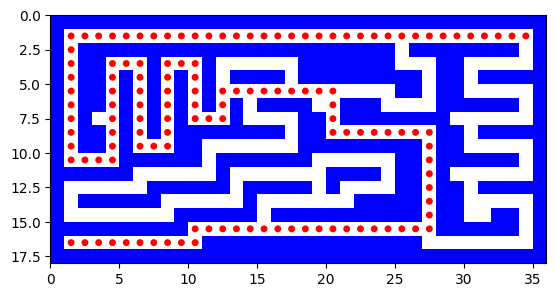

In [54]:
with open("/content/mediumMaze.lay", "r") as mediumMazefile:
    maze=list(mediumMazefile)


start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  print(' ')
  print(' ')
  maze_plot(li)


#Report for Depth-First-Search for medium Maze

In [55]:
print("Report for Depth-First-Search for medium Maze")
print(' ')

report([dfs], [problem],dfs_solution_path)

Report for Depth-First-Search for medium Maze
 
dfs:
Solution path is  [(1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (1, 24), (1, 23), (1, 22), (1, 21), (1, 20), (1, 19), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (10, 2), (10, 3), (10, 4), (9, 4), (8, 4), (7, 4), (6, 4), (5, 4), (4, 4), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (9, 7), (9, 8), (8, 8), (7, 8), (6, 8), (5, 8), (4, 8), (3, 8), (3, 9), (3, 10), (4, 10), (5, 10), (6, 10), (7, 10), (7, 11), (7, 12), (6, 12), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 19), (5, 20), (6, 20), (7, 20), (8, 20), (8, 21), (8, 22), (8, 23), (8, 24), (8, 25), (8, 26), (8, 27), (9, 27), (10, 27), (11, 27), (12, 27), (13, 27), (14, 27), (15, 27), (15, 26), (15, 25), (15, 24

#A* search for medium Maze

(1, 34) (16, 1)


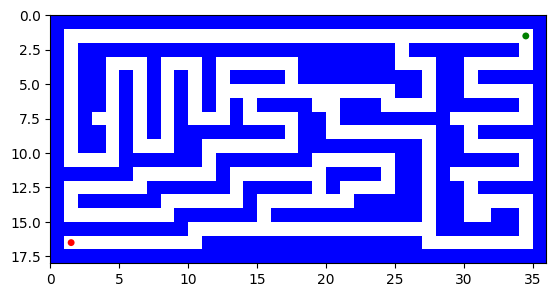

 
 path to reach from  (1, 34) to  (16, 1)  is
 
[(1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (2, 25), (3, 25), (3, 26), (3, 27), (4, 27), (5, 27), (6, 27), (6, 26), (6, 25), (6, 24), (5, 24), (5, 23), (5, 22), (5, 21), (5, 20), (6, 20), (7, 20), (8, 20), (8, 21), (8, 22), (8, 23), (8, 24), (8, 25), (8, 26), (8, 27), (9, 27), (10, 27), (11, 27), (12, 27), (13, 27), (14, 27), (15, 27), (15, 26), (15, 25), (15, 24), (15, 23), (15, 22), (15, 21), (15, 20), (15, 19), (15, 18), (15, 17), (15, 16), (15, 15), (15, 14), (15, 13), (15, 12), (15, 11), (15, 10), (16, 10), (16, 9), (16, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 3), (16, 2), (16, 1)]
 
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                        ..........%
% %%%%%%%%%%%%%%%%%%%%%%%.%%%%%%%% %
% %%   %   %      %%%%%%%...%%     %
% %% % % % % %%%% %%%%%%%%%.%% %%%%%
% %% % % % %        .....%%.%%     %
% %% % % % % % %%%% .%%%....%%%%%% %
% %  % % %   %    %%.%%%%%%%%      %
% %% % 

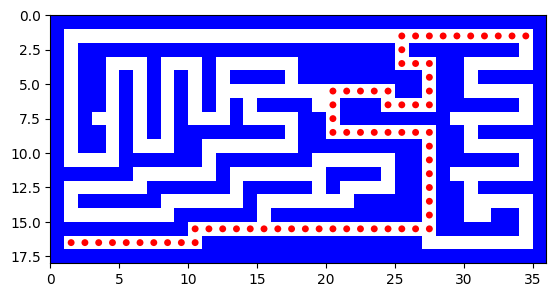

In [56]:
with open("/content/mediumMaze.lay", "r") as mediumMazefile:
    maze=list(mediumMazefile)


start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)


#Report for A* Search for medium Maze

In [57]:
print("Report for A* Search for medium Maze")
print(' ')

report([astar_search], [problem],astar_solution_path)

Report for A* Search for medium Maze
 
astar_search:
Solution path is  [(1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (2, 25), (3, 25), (3, 26), (3, 27), (4, 27), (5, 27), (6, 27), (6, 26), (6, 25), (6, 24), (5, 24), (5, 23), (5, 22), (5, 21), (5, 20), (6, 20), (7, 20), (8, 20), (8, 21), (8, 22), (8, 23), (8, 24), (8, 25), (8, 26), (8, 27), (9, 27), (10, 27), (11, 27), (12, 27), (13, 27), (14, 27), (15, 27), (15, 26), (15, 25), (15, 24), (15, 23), (15, 22), (15, 21), (15, 20), (15, 19), (15, 18), (15, 17), (15, 16), (15, 15), (15, 14), (15, 13), (15, 12), (15, 11), (15, 10), (16, 10), (16, 9), (16, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 3), (16, 2), (16, 1)] 

Number of nodes expanded 453 

Maximum size of finge 8 

Maximum tree depth searched: 68


#openMaze.lay

**Depth-First-Search for open maze**

(1, 35) (21, 1)


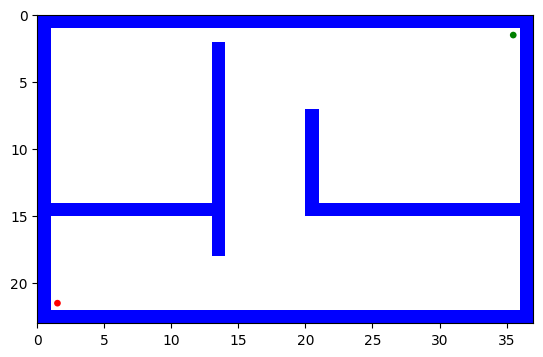

 
 path to reach from  (1, 35) to  (21, 1)  is
 
[(1, 35), (1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (1, 24), (1, 23), (1, 22), (1, 21), (1, 20), (1, 19), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (2, 14), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (3, 21), (3, 22), (3, 23), (3, 24), (3, 25), (3, 26), (3, 27), (3, 28), (3, 29), (3, 30), (3, 31), (3, 32), (3, 33), (3, 34), (3, 35), (4, 35), (5, 35), (5, 34), (5, 33), (5, 32), (5, 31), (5, 30), (5, 29), (5, 28), (5, 27), (5, 26), (5, 25), (5, 24), (5, 23), (5, 22), (5, 21), (5, 20), (5, 19), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (6, 14), (7, 14), (7, 15), (7, 16), (7, 17), (7, 18), (7, 19), (8, 19), (9, 19), (9, 18), (9, 17), (9, 16), (9, 15), (9, 14), (10, 14), (11, 14), (11, 15), (11, 16), (11, 17), (11, 18), (11, 19), (12, 19), (13, 19), (13, 18), (13, 17), (13, 16), (13, 15), (13, 14), (14, 14), (15, 14), (15, 15), (15, 16), (15, 17), (15, 18), (15, 19), (1

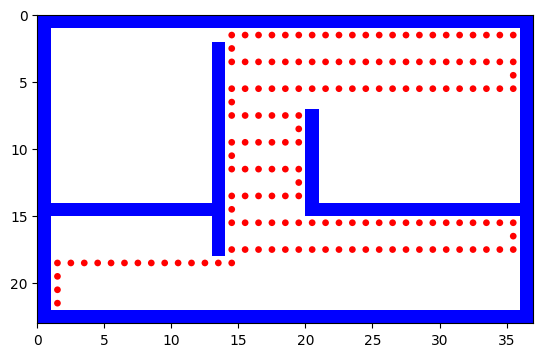

In [58]:
with open("/content/openMaze.lay", "r") as openMazefile:
    maze=list(openMazefile)



start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  print(' ')
  print(' ')
  maze_plot(li)


#Report for Depth-First-Search for open Maze

In [59]:
print("Report for Depth-First-Search for open Maze")
print(' ')

report([dfs], [problem],dfs_solution_path)

Report for Depth-First-Search for open Maze
 
dfs:
Solution path is  [(1, 35), (1, 34), (1, 33), (1, 32), (1, 31), (1, 30), (1, 29), (1, 28), (1, 27), (1, 26), (1, 25), (1, 24), (1, 23), (1, 22), (1, 21), (1, 20), (1, 19), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (2, 14), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (3, 21), (3, 22), (3, 23), (3, 24), (3, 25), (3, 26), (3, 27), (3, 28), (3, 29), (3, 30), (3, 31), (3, 32), (3, 33), (3, 34), (3, 35), (4, 35), (5, 35), (5, 34), (5, 33), (5, 32), (5, 31), (5, 30), (5, 29), (5, 28), (5, 27), (5, 26), (5, 25), (5, 24), (5, 23), (5, 22), (5, 21), (5, 20), (5, 19), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (6, 14), (7, 14), (7, 15), (7, 16), (7, 17), (7, 18), (7, 19), (8, 19), (9, 19), (9, 18), (9, 17), (9, 16), (9, 15), (9, 14), (10, 14), (11, 14), (11, 15), (11, 16), (11, 17), (11, 18), (11, 19), (12, 19), (13, 19), (13, 18), (13, 17), (13, 16), (13, 15), (13, 14), (14, 14), (15, 14), (15, 15), (15, 16), (15, 17), (1

#A* search for open Maze

The A* algorithm stands out among search algorithms such as Breadth-First Search (BFS) and Depth-First Search (DFS) for finding the shortest path to a goal state. While BFS and DFS can be effective for exploring and reaching a goal state, they do not guarantee the discovery of the shortest path. A* combines the advantages of both informed and uninformed search by using a heuristic to prioritize the most promising paths. This makes it particularly efficient in finding the optimal solution, as it evaluates nodes based on both the cost to reach them and an estimate of the remaining cost to the goal. Consequently, A* not only reaches the goal state but does so via the shortest path, making it a powerful tool for pathfinding in various applications such as robotics, game development, and navigation systems.

(1, 35) (21, 1)


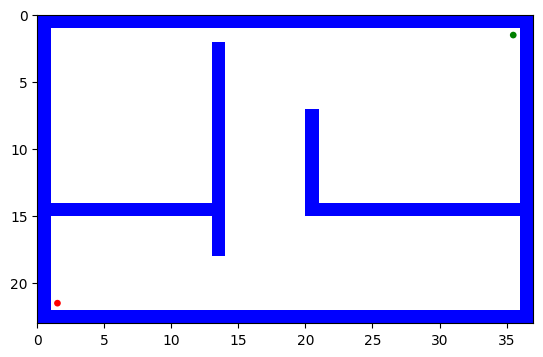

 
 path to reach from  (1, 35) to  (21, 1)  is
 
[(1, 35), (2, 35), (3, 35), (4, 35), (4, 34), (4, 33), (5, 33), (6, 33), (6, 32), (6, 31), (6, 30), (6, 29), (6, 28), (6, 27), (6, 26), (6, 25), (6, 24), (6, 23), (6, 22), (6, 21), (6, 20), (6, 19), (6, 18), (6, 17), (6, 16), (6, 15), (6, 14), (7, 14), (8, 14), (9, 14), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14), (15, 14), (16, 14), (17, 14), (18, 14), (18, 13), (18, 12), (18, 11), (18, 10), (18, 9), (18, 8), (18, 7), (18, 6), (18, 5), (18, 4), (19, 4), (20, 4), (20, 3), (21, 3), (21, 2), (21, 1)]
 
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                  .%
%            %                     .%
%            %                     .%
%            %                   ...%
%            %                   .  %
%            %....................  %
%            %.     %               %
%            %.     %               %
%            %.     %               %
%            %.     %               %
%            %.     % 

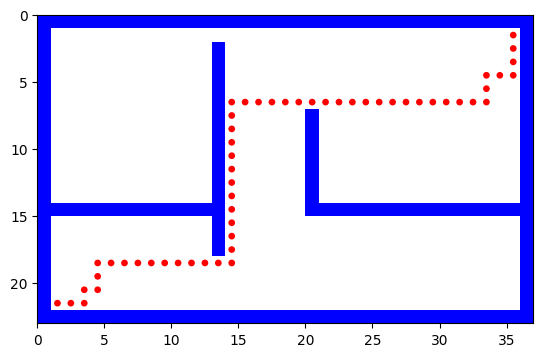

In [60]:
with open("/content/openMaze.lay", "r") as openMazefile:
    maze=list(openMazefile)



start = None
goal = None
mutiple_goals={}
k=0
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,goal)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)
  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)


#Report for A* Search for open Maze

In [61]:
print("Report for A* Search for open Maze")
print(' ')

report([astar_search], [problem],astar_solution_path)

Report for A* Search for open Maze
 
astar_search:
Solution path is  [(1, 35), (2, 35), (3, 35), (4, 35), (4, 34), (4, 33), (5, 33), (6, 33), (6, 32), (6, 31), (6, 30), (6, 29), (6, 28), (6, 27), (6, 26), (6, 25), (6, 24), (6, 23), (6, 22), (6, 21), (6, 20), (6, 19), (6, 18), (6, 17), (6, 16), (6, 15), (6, 14), (7, 14), (8, 14), (9, 14), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14), (15, 14), (16, 14), (17, 14), (18, 14), (18, 13), (18, 12), (18, 11), (18, 10), (18, 9), (18, 8), (18, 7), (18, 6), (18, 5), (18, 4), (19, 4), (20, 4), (20, 3), (21, 3), (21, 2), (21, 1)] 

Number of nodes expanded 1985 

Maximum size of finge 28 

Maximum tree depth searched: 54


#smallSearch.lay

**Depth-First-Search**

(1, 16) {0: (1, 1), 1: (1, 13), 2: (1, 14), 3: (1, 15), 4: (1, 18), 5: (2, 1), 6: (2, 4), 7: (2, 7), 8: (2, 10), 9: (2, 13), 10: (2, 18), 11: (3, 6), 12: (3, 7), 13: (3, 8), 14: (3, 9), 15: (3, 10), 16: (3, 18)}


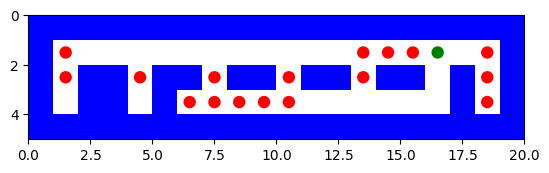

 
 
 path to reach from  (1, 16) to  (1, 1)  is
 
[(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


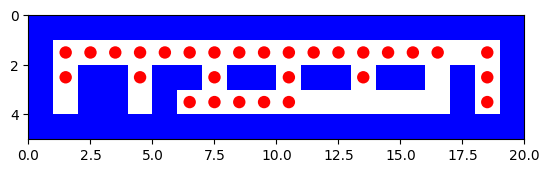

 
dfs:
Solution path is  [(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 41 

Maximum size of finge 5 

Maximum tree depth searched: 15
 
 
 path to reach from  (1, 1) to  (1, 13)  is
 
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


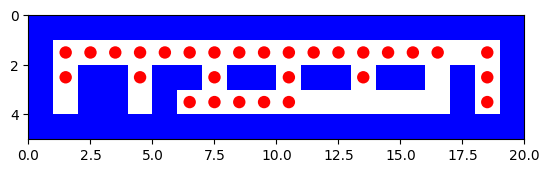

 
dfs:
Solution path is  [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)] 

Number of nodes expanded 27 

Maximum size of finge 4 

Maximum tree depth searched: 12
 
 
 path to reach from  (1, 13) to  (1, 14)  is
 
[(1, 13), (1, 14)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


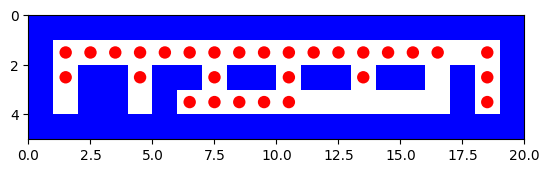

 
dfs:
Solution path is  [(1, 13), (1, 14)] 

Number of nodes expanded 3 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 14) to  (1, 15)  is
 
[(1, 14), (1, 15)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


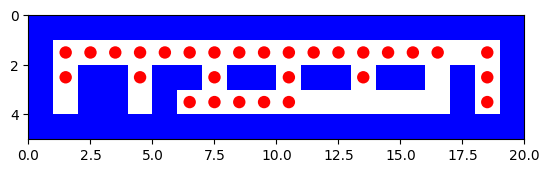

 
dfs:
Solution path is  [(1, 14), (1, 15)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 15) to  (1, 18)  is
 
[(1, 15), (1, 16), (1, 17), (1, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


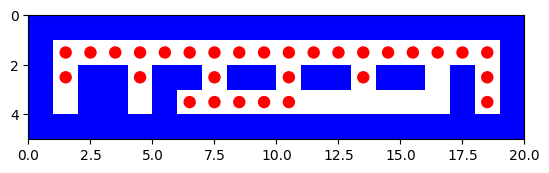

 
dfs:
Solution path is  [(1, 15), (1, 16), (1, 17), (1, 18)] 

Number of nodes expanded 7 

Maximum size of finge 2 

Maximum tree depth searched: 3
 
 
 path to reach from  (1, 18) to  (2, 1)  is
 
[(1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


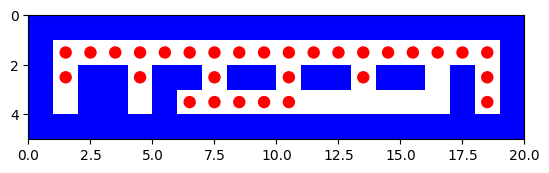

 
dfs:
Solution path is  [(1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)] 

Number of nodes expanded 40 

Maximum size of finge 6 

Maximum tree depth searched: 18
 
 
 path to reach from  (2, 1) to  (2, 4)  is
 
[(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


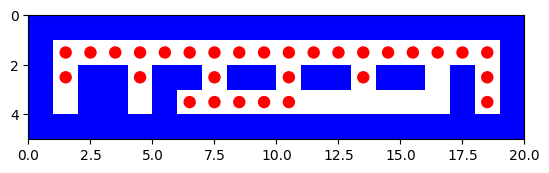

 
dfs:
Solution path is  [(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)] 

Number of nodes expanded 10 

Maximum size of finge 1 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 4) to  (2, 7)  is
 
[(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


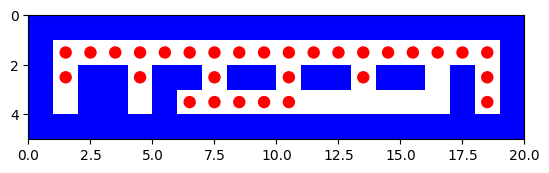

 
dfs:
Solution path is  [(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)] 

Number of nodes expanded 11 

Maximum size of finge 1 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 7) to  (2, 10)  is
 
[(2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


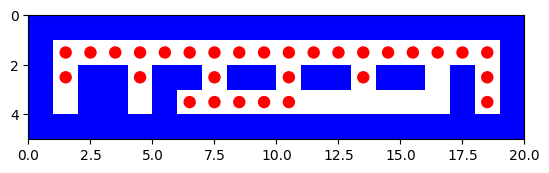

 
dfs:
Solution path is  [(2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10)] 

Number of nodes expanded 10 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 10) to  (2, 13)  is
 
[(2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %........   %.%
%%%%%%%%%%%%%%%%%%%%


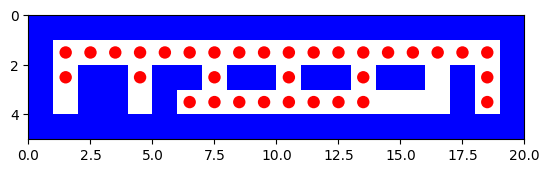

 
dfs:
Solution path is  [(2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13)] 

Number of nodes expanded 10 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 13) to  (2, 18)  is
 
[(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


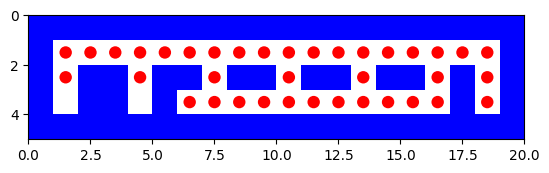

 
dfs:
Solution path is  [(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18)] 

Number of nodes expanded 19 

Maximum size of finge 3 

Maximum tree depth searched: 9
 
 
 path to reach from  (2, 18) to  (3, 6)  is
 
[(2, 18), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (2, 7), (3, 7), (3, 6)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


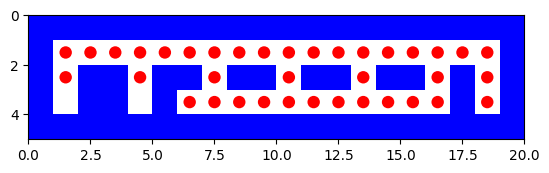

 
dfs:
Solution path is  [(2, 18), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (2, 7), (3, 7), (3, 6)] 

Number of nodes expanded 54 

Maximum size of finge 5 

Maximum tree depth searched: 15
 
 
 path to reach from  (3, 6) to  (3, 7)  is
 
[(3, 6), (3, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


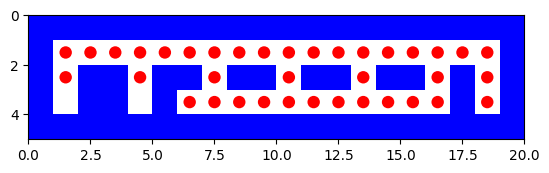

 
dfs:
Solution path is  [(3, 6), (3, 7)] 

Number of nodes expanded 1 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 7) to  (3, 8)  is
 
[(3, 7), (3, 8)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


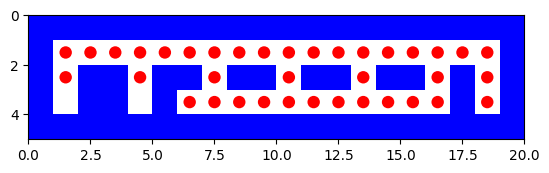

 
dfs:
Solution path is  [(3, 7), (3, 8)] 

Number of nodes expanded 3 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 8) to  (3, 9)  is
 
[(3, 8), (3, 9)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


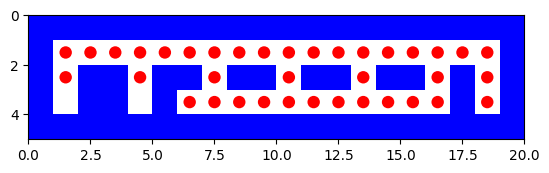

 
dfs:
Solution path is  [(3, 8), (3, 9)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 9) to  (3, 10)  is
 
[(3, 9), (3, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


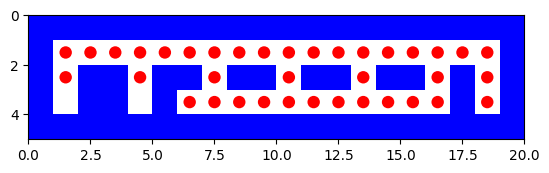

 
dfs:
Solution path is  [(3, 9), (3, 10)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 10) to  (3, 18)  is
 
[(3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


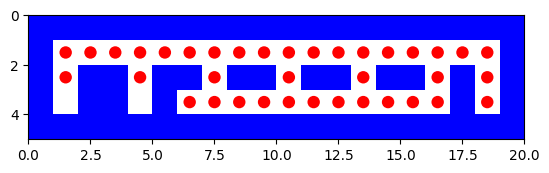

 
dfs:
Solution path is  [(3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18)] 

Number of nodes expanded 27 

Maximum size of finge 4 

Maximum tree depth searched: 12
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%
overall path


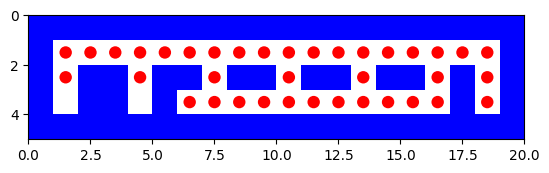

final path from starting point to the last goal [(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 13), (1, 14), (1, 14), (1, 15), (1, 15), (1, 16), (1, 17), (1, 18), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7), (2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10), (2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13), (2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (2, 18), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (2, 7), (3, 7), (3, 6), (3, 6), (3, 7), (3, 7), (3, 8), (3, 8), (3, 9),

In [62]:
import string
with open("/content/smallSearch.lay", "r") as smallSearchfile:
    maze=list(smallSearchfile)

start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    Final_path+=dfs_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([dfs], [problem],dfs_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)

A* search for smallSearch

(1, 16) {0: (1, 1), 1: (1, 13), 2: (1, 14), 3: (1, 15), 4: (1, 18), 5: (2, 1), 6: (2, 4), 7: (2, 7), 8: (2, 10), 9: (2, 13), 10: (2, 18), 11: (3, 6), 12: (3, 7), 13: (3, 8), 14: (3, 9), 15: (3, 10), 16: (3, 18)}


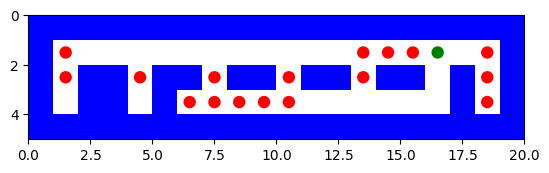

 
 
 path to reach from  (1, 16) to  (1, 1)  is
 
[(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


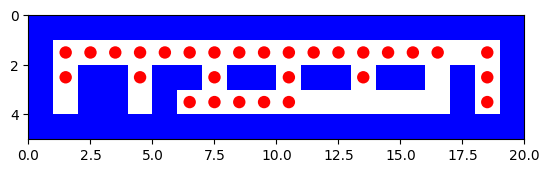

 
astar_search:
Solution path is  [(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 35 

Maximum size of finge 7 

Maximum tree depth searched: 15
 
 
 path to reach from  (1, 1) to  (1, 13)  is
 
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


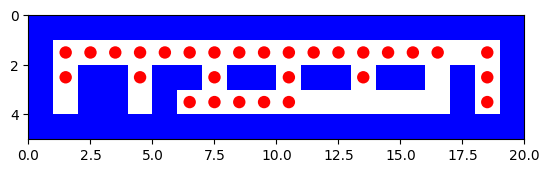

 
astar_search:
Solution path is  [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)] 

Number of nodes expanded 27 

Maximum size of finge 5 

Maximum tree depth searched: 12
 
 
 path to reach from  (1, 13) to  (1, 14)  is
 
[(1, 13), (1, 14)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


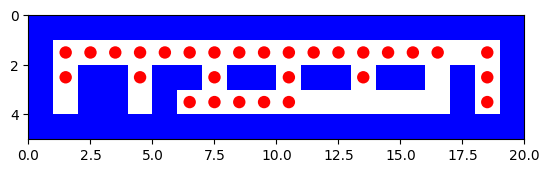

 
astar_search:
Solution path is  [(1, 13), (1, 14)] 

Number of nodes expanded 3 

Maximum size of finge 3 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 14) to  (1, 15)  is
 
[(1, 14), (1, 15)]
 
%%%%%%%%%%%%%%%%%%%%
%................ .%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


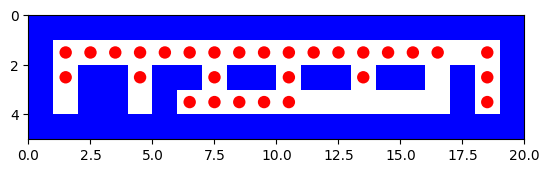

 
astar_search:
Solution path is  [(1, 14), (1, 15)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 15) to  (1, 18)  is
 
[(1, 15), (1, 16), (1, 17), (1, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


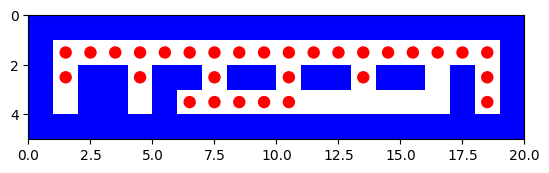

 
astar_search:
Solution path is  [(1, 15), (1, 16), (1, 17), (1, 18)] 

Number of nodes expanded 7 

Maximum size of finge 3 

Maximum tree depth searched: 3
 
 
 path to reach from  (1, 18) to  (2, 1)  is
 
[(1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


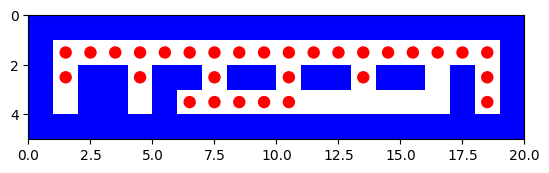

 
astar_search:
Solution path is  [(1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)] 

Number of nodes expanded 53 

Maximum size of finge 7 

Maximum tree depth searched: 18
 
 
 path to reach from  (2, 1) to  (2, 4)  is
 
[(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


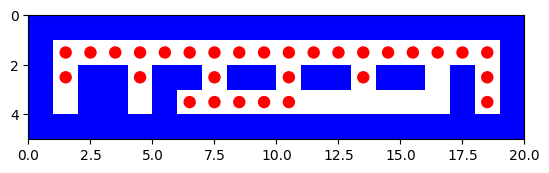

 
astar_search:
Solution path is  [(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)] 

Number of nodes expanded 12 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 4) to  (2, 7)  is
 
[(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


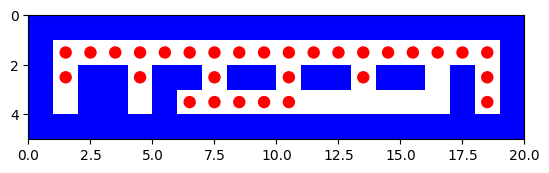

 
astar_search:
Solution path is  [(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)] 

Number of nodes expanded 13 

Maximum size of finge 3 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 7) to  (2, 10)  is
 
[(2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


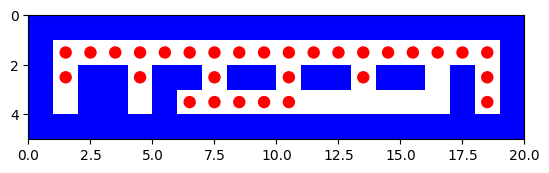

 
astar_search:
Solution path is  [(2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10)] 

Number of nodes expanded 22 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 10) to  (2, 13)  is
 
[(2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


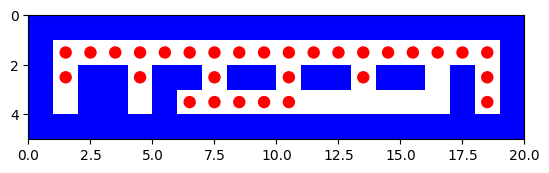

 
astar_search:
Solution path is  [(2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13)] 

Number of nodes expanded 22 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 13) to  (2, 18)  is
 
[(2, 13), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (2, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%% %.%
% %% %.....      %.%
%%%%%%%%%%%%%%%%%%%%


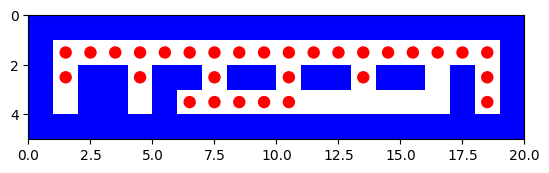

 
astar_search:
Solution path is  [(2, 13), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (2, 18)] 

Number of nodes expanded 27 

Maximum size of finge 5 

Maximum tree depth searched: 7
 
 
 path to reach from  (2, 18) to  (3, 6)  is
 
[(2, 18), (1, 18), (1, 17), (1, 16), (2, 16), (3, 16), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (3, 10), (3, 9), (3, 8), (3, 7), (3, 6)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


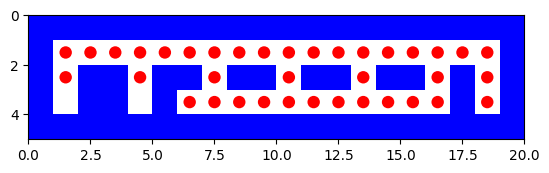

 
astar_search:
Solution path is  [(2, 18), (1, 18), (1, 17), (1, 16), (2, 16), (3, 16), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (3, 10), (3, 9), (3, 8), (3, 7), (3, 6)] 

Number of nodes expanded 64 

Maximum size of finge 3 

Maximum tree depth searched: 15
 
 
 path to reach from  (3, 6) to  (3, 7)  is
 
[(3, 6), (3, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


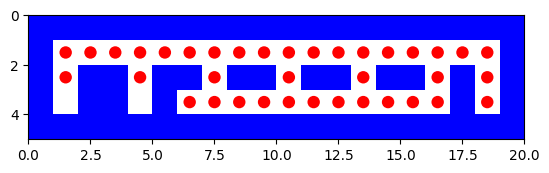

 
astar_search:
Solution path is  [(3, 6), (3, 7)] 

Number of nodes expanded 1 

Maximum size of finge 1 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 7) to  (3, 8)  is
 
[(3, 7), (3, 8)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


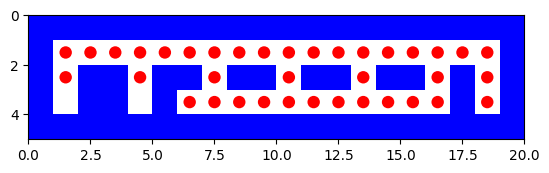

 
astar_search:
Solution path is  [(3, 7), (3, 8)] 

Number of nodes expanded 3 

Maximum size of finge 3 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 8) to  (3, 9)  is
 
[(3, 8), (3, 9)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


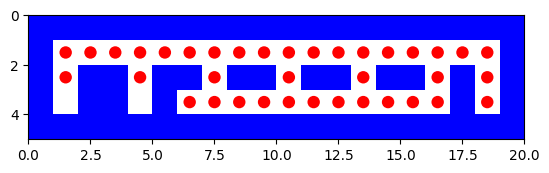

 
astar_search:
Solution path is  [(3, 8), (3, 9)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 9) to  (3, 10)  is
 
[(3, 9), (3, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


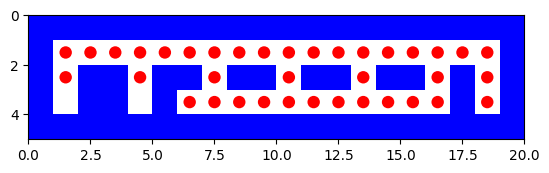

 
astar_search:
Solution path is  [(3, 9), (3, 10)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (3, 10) to  (3, 18)  is
 
[(3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18)]
 
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%


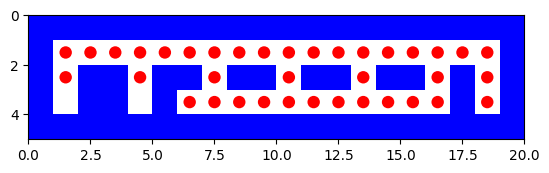

 
astar_search:
Solution path is  [(3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18)] 

Number of nodes expanded 49 

Maximum size of finge 5 

Maximum tree depth searched: 12
%%%%%%%%%%%%%%%%%%%%
%..................%
%.%%.%%.%%.%%.%%.%.%
% %% %...........%.%
%%%%%%%%%%%%%%%%%%%%
overall path


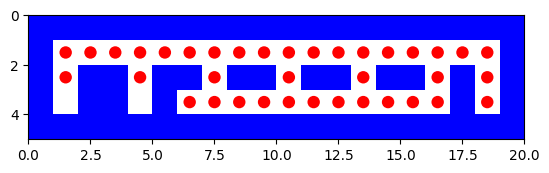

final path from starting point to the last goal [(1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 13), (1, 14), (1, 14), (1, 15), (1, 15), (1, 16), (1, 17), (1, 18), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7), (2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10), (2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13), (2, 13), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (2, 18), (2, 18), (1, 18), (1, 17), (1, 16), (2, 16), (3, 16), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (3, 10), (3, 9), (3, 8), (3, 7), (3, 6), (3, 6), (3, 7), (3, 7), (3, 8), (3, 8), (3, 9), (3, 9), (3, 10)

In [63]:
import string
with open("/content/smallSearch.lay", "r") as smallSearchfile:
    maze=list(smallSearchfile)

start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node= astar_search(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    Final_path+=astar_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([astar_search], [problem],astar_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)


#trickySearch.lay

**Depth-First-Search**

(3, 9) {0: (1, 1), 1: (1, 13), 2: (1, 14), 3: (2, 1), 4: (2, 4), 5: (2, 7), 6: (2, 10), 7: (2, 13), 8: (5, 1), 9: (5, 2), 10: (5, 3), 11: (5, 4), 12: (5, 5)}


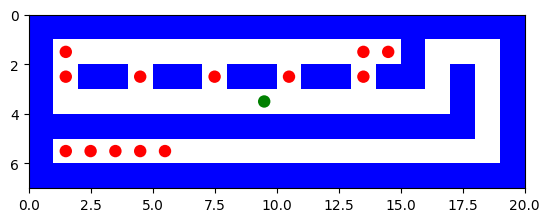

 
 
 path to reach from  (3, 9) to  (1, 1)  is
 
[(3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%        .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


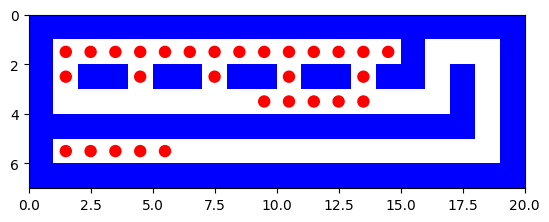

 
dfs:
Solution path is  [(3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 97 

Maximum size of finge 4 

Maximum tree depth searched: 18
 
 
 path to reach from  (1, 1) to  (1, 13)  is
 
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%        .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


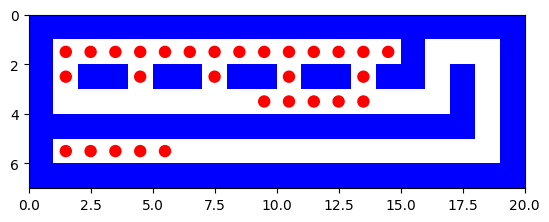

 
dfs:
Solution path is  [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)] 

Number of nodes expanded 27 

Maximum size of finge 4 

Maximum tree depth searched: 12
 
 
 path to reach from  (1, 13) to  (1, 14)  is
 
[(1, 13), (1, 14)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%        .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


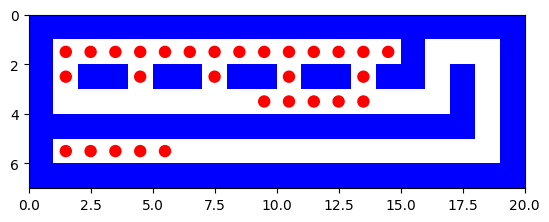

 
dfs:
Solution path is  [(1, 13), (1, 14)] 

Number of nodes expanded 3 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 14) to  (2, 1)  is
 
[(1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%        .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


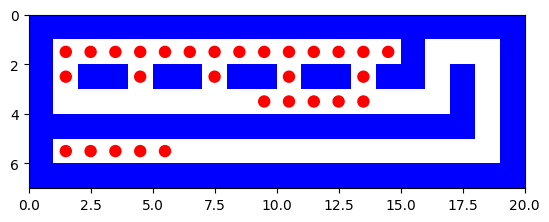

 
dfs:
Solution path is  [(1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)] 

Number of nodes expanded 30 

Maximum size of finge 4 

Maximum tree depth searched: 14
 
 
 path to reach from  (2, 1) to  (2, 4)  is
 
[(2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (2, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%....    .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


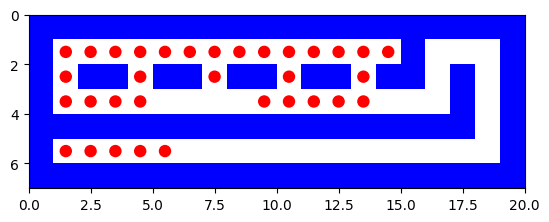

 
dfs:
Solution path is  [(2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (2, 4)] 

Number of nodes expanded 9 

Maximum size of finge 1 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 4) to  (2, 7)  is
 
[(2, 4), (3, 4), (3, 5), (3, 6), (3, 7), (2, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%....... .....   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


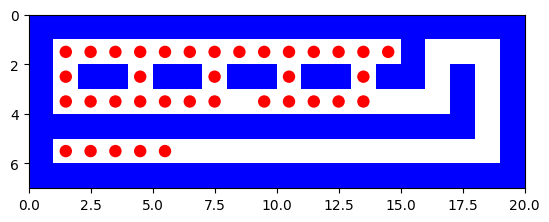

 
dfs:
Solution path is  [(2, 4), (3, 4), (3, 5), (3, 6), (3, 7), (2, 7)] 

Number of nodes expanded 10 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 7) to  (2, 10)  is
 
[(2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%.............   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


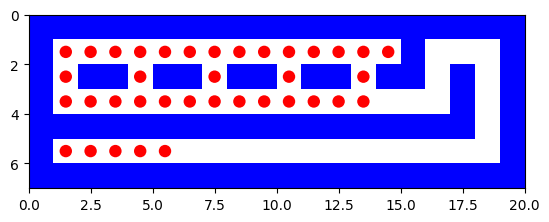

 
dfs:
Solution path is  [(2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10)] 

Number of nodes expanded 10 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 10) to  (2, 13)  is
 
[(2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%.............   % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


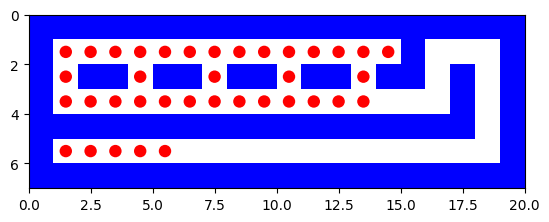

 
dfs:
Solution path is  [(2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13)] 

Number of nodes expanded 10 

Maximum size of finge 2 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 13) to  (5, 1)  is
 
[(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


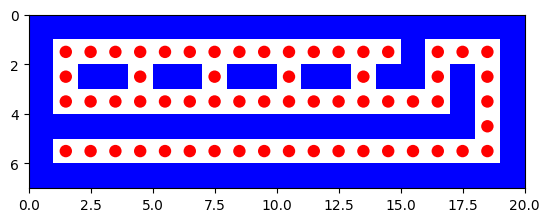

 
dfs:
Solution path is  [(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1)] 

Number of nodes expanded 58 

Maximum size of finge 2 

Maximum tree depth searched: 29
 
 
 path to reach from  (5, 1) to  (5, 2)  is
 
[(5, 1), (5, 2)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


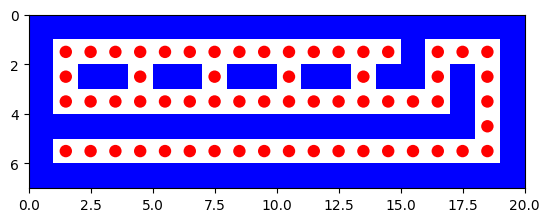

 
dfs:
Solution path is  [(5, 1), (5, 2)] 

Number of nodes expanded 1 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 2) to  (5, 3)  is
 
[(5, 2), (5, 3)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


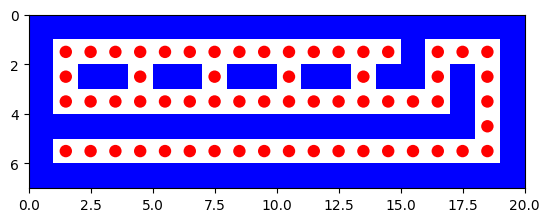

 
dfs:
Solution path is  [(5, 2), (5, 3)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 3) to  (5, 4)  is
 
[(5, 3), (5, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


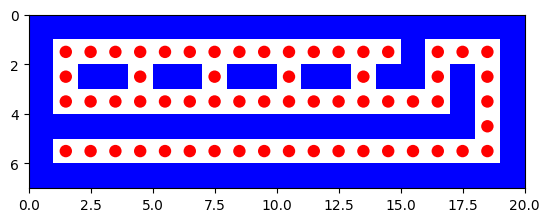

 
dfs:
Solution path is  [(5, 3), (5, 4)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 4) to  (5, 5)  is
 
[(5, 4), (5, 5)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


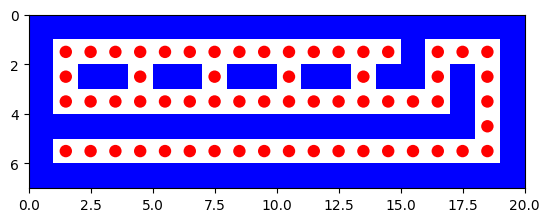

 
dfs:
Solution path is  [(5, 4), (5, 5)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%................%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%
overall path


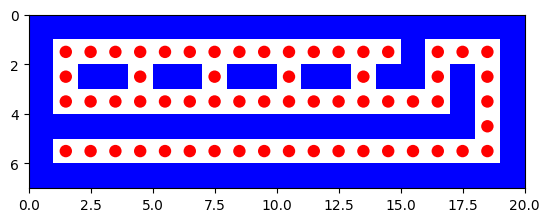

final path from starting point to the last goal [(3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 13), (1, 14), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (2, 4), (2, 4), (3, 4), (3, 5), (3, 6), (3, 7), (2, 7), (2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (2, 10), (2, 10), (3, 10), (3, 11), (3, 12), (3, 13), (2, 13), (2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (5, 1), (5, 2), (5, 2), (5, 3), (5, 3), (5, 4), (5, 4), (5, 5)]


In [64]:

with open("/content/trickySearch.lay", "r") as trickySearchfile:
    maze=list(trickySearchfile)


start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    Final_path+=dfs_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([dfs], [problem],dfs_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)


#A* search

(3, 9) {0: (1, 1), 1: (1, 13), 2: (1, 14), 3: (2, 1), 4: (2, 4), 5: (2, 7), 6: (2, 10), 7: (2, 13), 8: (5, 1), 9: (5, 2), 10: (5, 3), 11: (5, 4), 12: (5, 5)}


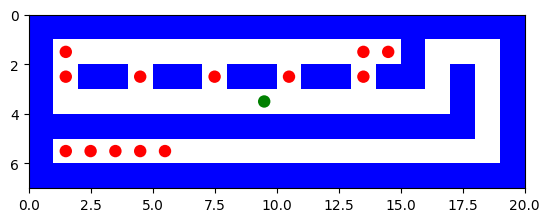

 
 
 path to reach from  (3, 9) to  (1, 1)  is
 
[(3, 9), (3, 8), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%.......     ..%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


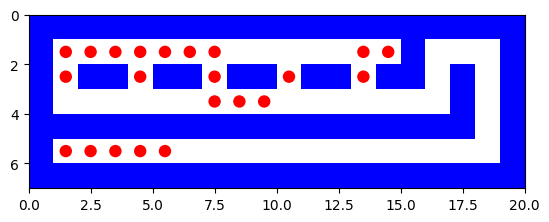

 
astar_search:
Solution path is  [(3, 9), (3, 8), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 40 

Maximum size of finge 5 

Maximum tree depth searched: 10
 
 
 path to reach from  (1, 1) to  (1, 13)  is
 
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


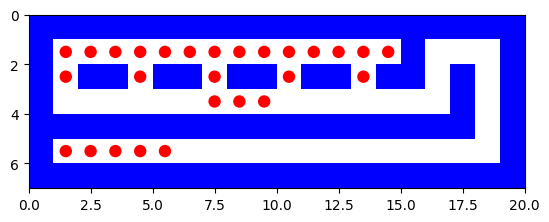

 
astar_search:
Solution path is  [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)] 

Number of nodes expanded 27 

Maximum size of finge 5 

Maximum tree depth searched: 12
 
 
 path to reach from  (1, 13) to  (1, 14)  is
 
[(1, 13), (1, 14)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


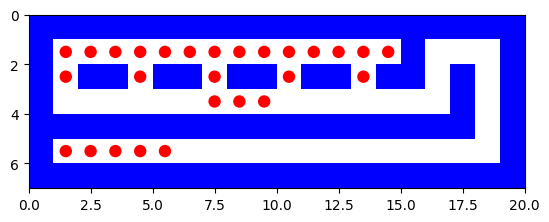

 
astar_search:
Solution path is  [(1, 13), (1, 14)] 

Number of nodes expanded 3 

Maximum size of finge 3 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 14) to  (2, 1)  is
 
[(1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


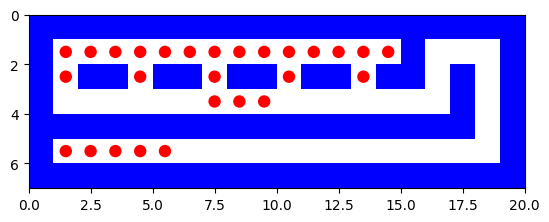

 
astar_search:
Solution path is  [(1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1)] 

Number of nodes expanded 39 

Maximum size of finge 5 

Maximum tree depth searched: 14
 
 
 path to reach from  (2, 1) to  (2, 4)  is
 
[(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


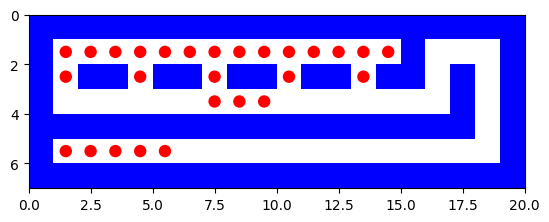

 
astar_search:
Solution path is  [(2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4)] 

Number of nodes expanded 20 

Maximum size of finge 3 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 4) to  (2, 7)  is
 
[(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


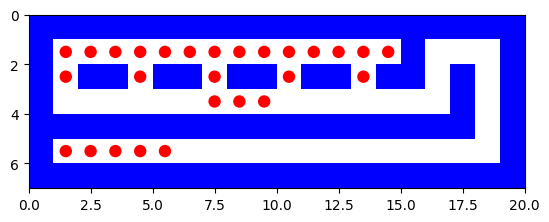

 
astar_search:
Solution path is  [(2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7)] 

Number of nodes expanded 22 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 7) to  (2, 10)  is
 
[(2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


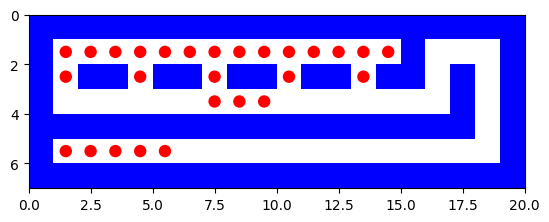

 
astar_search:
Solution path is  [(2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10)] 

Number of nodes expanded 22 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 10) to  (2, 13)  is
 
[(2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%   %
%.%%.%%.%%.%%.%% % %
%      ...       % %
%%%%%%%%%%%%%%%%%% %
%.....             %
%%%%%%%%%%%%%%%%%%%%


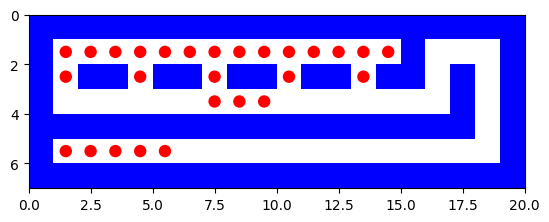

 
astar_search:
Solution path is  [(2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13)] 

Number of nodes expanded 22 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (2, 13) to  (5, 1)  is
 
[(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


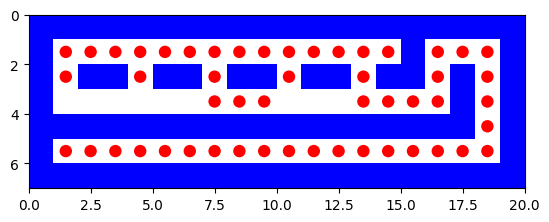

 
astar_search:
Solution path is  [(2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1)] 

Number of nodes expanded 125 

Maximum size of finge 7 

Maximum tree depth searched: 29
 
 
 path to reach from  (5, 1) to  (5, 2)  is
 
[(5, 1), (5, 2)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


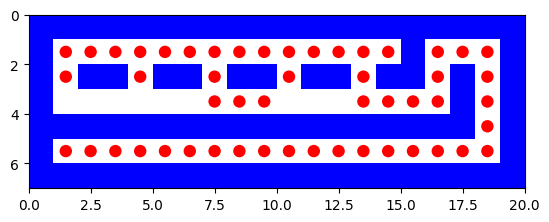

 
astar_search:
Solution path is  [(5, 1), (5, 2)] 

Number of nodes expanded 1 

Maximum size of finge 1 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 2) to  (5, 3)  is
 
[(5, 2), (5, 3)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


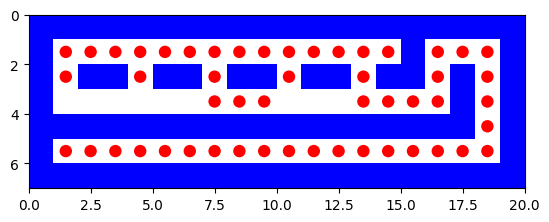

 
astar_search:
Solution path is  [(5, 2), (5, 3)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 3) to  (5, 4)  is
 
[(5, 3), (5, 4)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


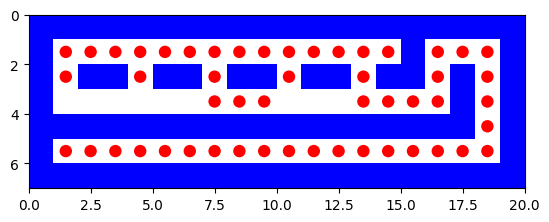

 
astar_search:
Solution path is  [(5, 3), (5, 4)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (5, 4) to  (5, 5)  is
 
[(5, 4), (5, 5)]
 
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%


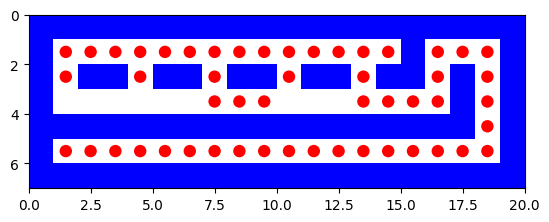

 
astar_search:
Solution path is  [(5, 4), (5, 5)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
%%%%%%%%%%%%%%%%%%%%
%..............%...%
%.%%.%%.%%.%%.%%.%.%
%      ...   ....%.%
%%%%%%%%%%%%%%%%%%.%
%..................%
%%%%%%%%%%%%%%%%%%%%
overall path


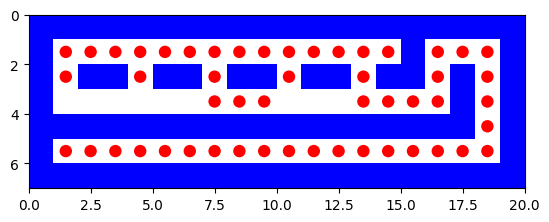

final path from starting point to the last goal [(3, 9), (3, 8), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 13), (1, 14), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 1), (2, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7), (2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10), (2, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13), (2, 13), (3, 13), (3, 14), (3, 15), (3, 16), (2, 16), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (5, 17), (5, 16), (5, 15), (5, 14), (5, 13), (5, 12), (5, 11), (5, 10), (5, 9), (5, 8), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (5, 1), (5, 2), (5, 2), (5, 3), (5, 3), (5, 4), (5, 4), (5, 5)]


In [65]:

with open("/content/trickySearch.lay", "r") as trickySearchfile:
    maze=list(trickySearchfile)


start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    Final_path+=astar_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([astar_search], [problem],astar_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)


#tinySearch.lay

#Depth-First-Search

(3, 4) {0: (1, 1), 1: (1, 2), 2: (1, 6), 3: (1, 7), 4: (2, 4), 5: (4, 1), 6: (4, 7), 7: (5, 1), 8: (5, 3), 9: (5, 7)}


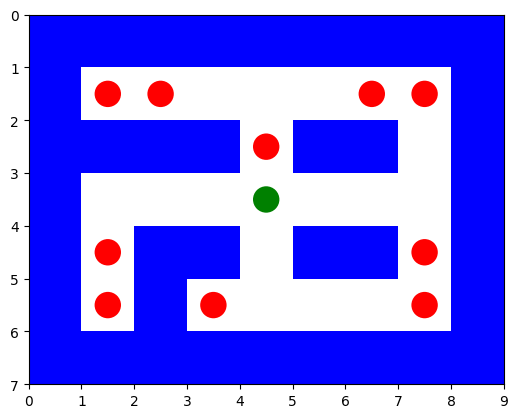

 
 
 path to reach from  (3, 4) to  (1, 1)  is
 
[(3, 4), (3, 5), (3, 6), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%   ....%
%.%% %%.%
%.%.   .%
%%%%%%%%%


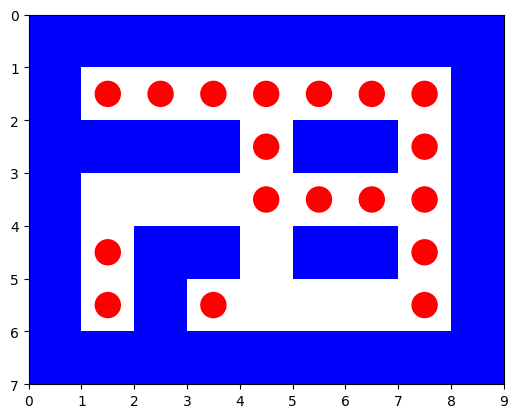

 
dfs:
Solution path is  [(3, 4), (3, 5), (3, 6), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 37 

Maximum size of finge 4 

Maximum tree depth searched: 11
 
 
 path to reach from  (1, 1) to  (1, 2)  is
 
[(1, 1), (1, 2)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%   ....%
%.%% %%.%
%.%.   .%
%%%%%%%%%


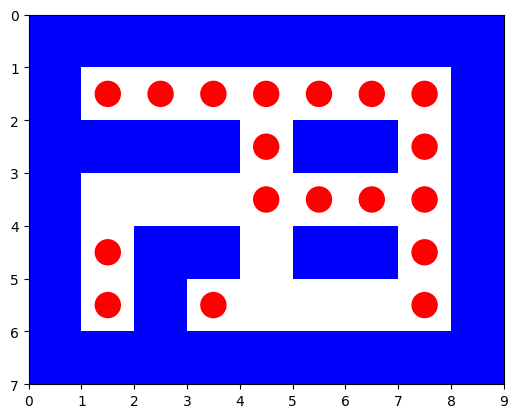

 
dfs:
Solution path is  [(1, 1), (1, 2)] 

Number of nodes expanded 1 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 2) to  (1, 6)  is
 
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%   ....%
%.%% %%.%
%.%.   .%
%%%%%%%%%


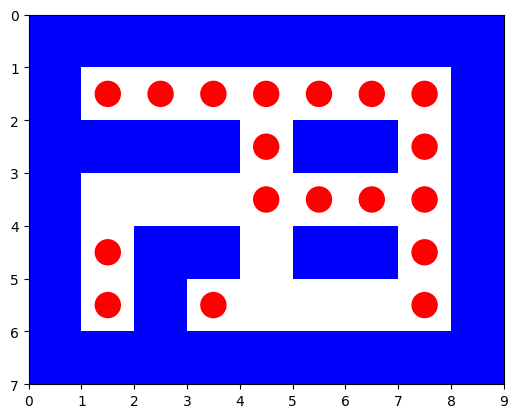

 
dfs:
Solution path is  [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)] 

Number of nodes expanded 9 

Maximum size of finge 2 

Maximum tree depth searched: 4
 
 
 path to reach from  (1, 6) to  (1, 7)  is
 
[(1, 6), (1, 7)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%   ....%
%.%% %%.%
%.%.   .%
%%%%%%%%%


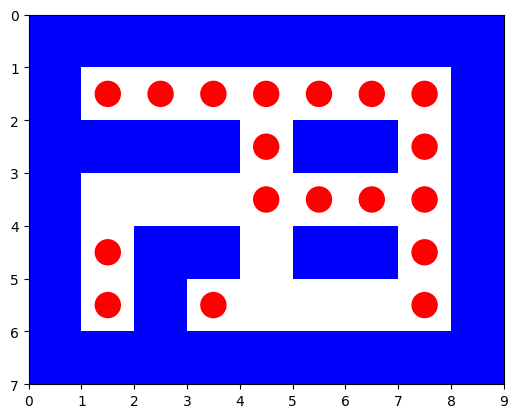

 
dfs:
Solution path is  [(1, 6), (1, 7)] 

Number of nodes expanded 2 

Maximum size of finge 0 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 7) to  (2, 4)  is
 
[(1, 7), (1, 6), (1, 5), (1, 4), (2, 4)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%   ....%
%.%% %%.%
%.%.   .%
%%%%%%%%%


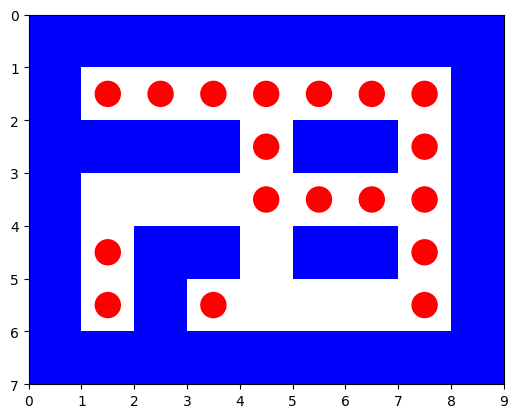

 
dfs:
Solution path is  [(1, 7), (1, 6), (1, 5), (1, 4), (2, 4)] 

Number of nodes expanded 7 

Maximum size of finge 1 

Maximum tree depth searched: 4
 
 
 path to reach from  (2, 4) to  (4, 1)  is
 
[(2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%% %%.%
%.%.   .%
%%%%%%%%%


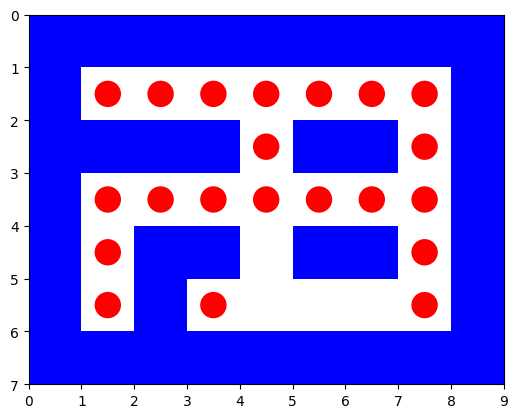

 
dfs:
Solution path is  [(2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1)] 

Number of nodes expanded 38 

Maximum size of finge 4 

Maximum tree depth searched: 5
 
 
 path to reach from  (4, 1) to  (4, 7)  is
 
[(4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%% %%.%
%.%.   .%
%%%%%%%%%


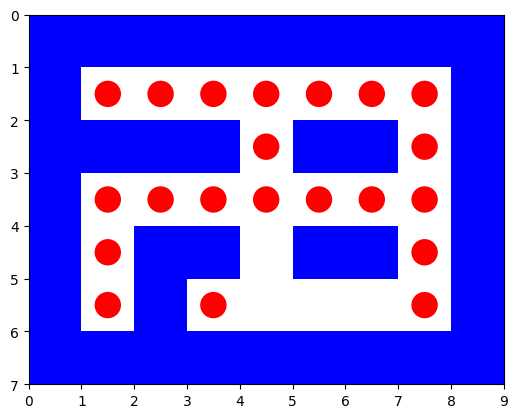

 
dfs:
Solution path is  [(4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7)] 

Number of nodes expanded 19 

Maximum size of finge 2 

Maximum tree depth searched: 8
 
 
 path to reach from  (4, 7) to  (5, 1)  is
 
[(4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%


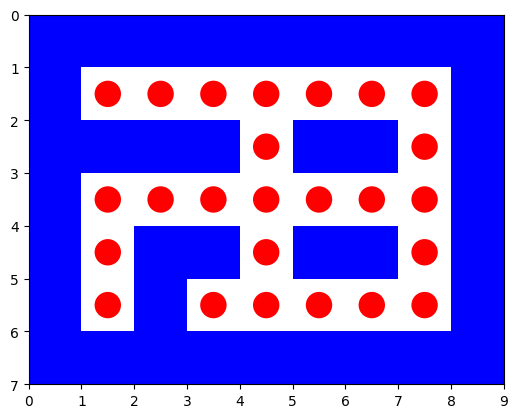

 
dfs:
Solution path is  [(4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1)] 

Number of nodes expanded 30 

Maximum size of finge 3 

Maximum tree depth searched: 11
 
 
 path to reach from  (5, 1) to  (5, 3)  is
 
[(5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%


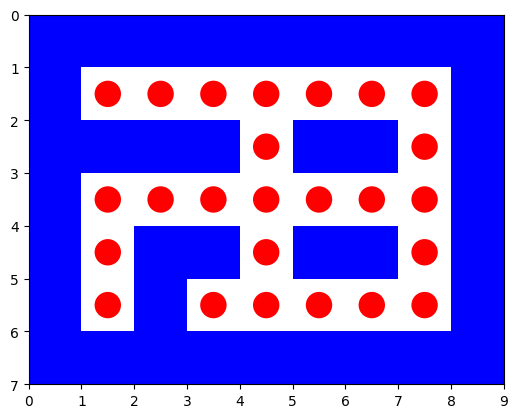

 
dfs:
Solution path is  [(5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3)] 

Number of nodes expanded 30 

Maximum size of finge 3 

Maximum tree depth searched: 14
 
 
 path to reach from  (5, 3) to  (5, 7)  is
 
[(5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
 
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%


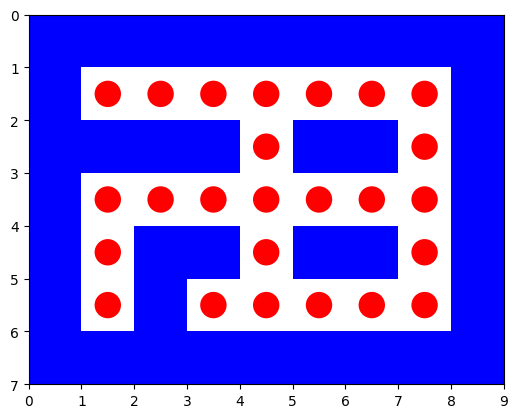

 
dfs:
Solution path is  [(5, 3), (5, 4), (5, 5), (5, 6), (5, 7)] 

Number of nodes expanded 8 

Maximum size of finge 1 

Maximum tree depth searched: 4
%%%%%%%%%
%.......%
%%%%.%%.%
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%
overall path


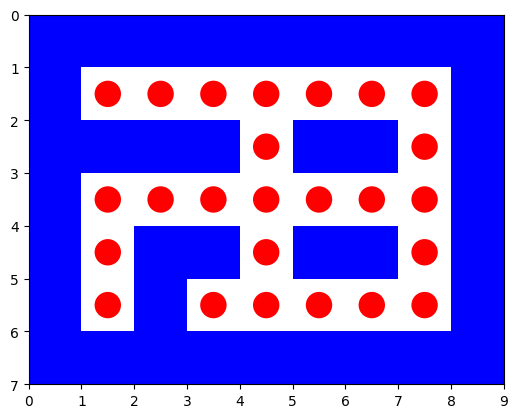

final path from starting point to the last goal [(3, 4), (3, 5), (3, 6), (3, 7), (2, 7), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 6), (1, 7), (1, 7), (1, 6), (1, 5), (1, 4), (2, 4), (2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1), (5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (5, 7), (5, 6), (5, 5), (5, 4), (5, 3), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]


In [66]:

with open("/content/tinySearch.lay", "r") as tinySearchfile:
    maze=list(tinySearchfile)


start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = dfs(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    dfs_solution_path = path_states(solution_node.node)
    Final_path+=dfs_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(dfs_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in dfs_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([dfs], [problem],dfs_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)


A* search for tinySearch including report for each goal state

(3, 4) {0: (1, 1), 1: (1, 2), 2: (1, 6), 3: (1, 7), 4: (2, 4), 5: (4, 1), 6: (4, 7), 7: (5, 1), 8: (5, 3), 9: (5, 7)}


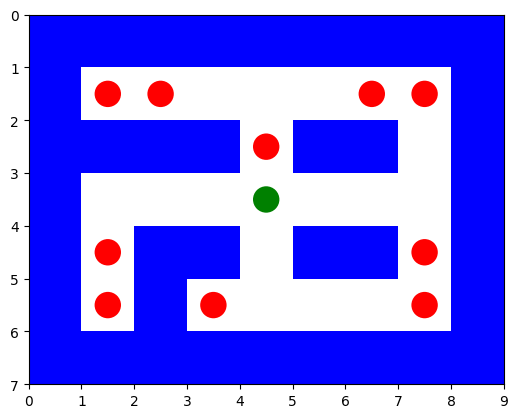

 
 
 path to reach from  (3, 4) to  (1, 1)  is
 
[(3, 4), (2, 4), (1, 4), (1, 3), (1, 2), (1, 1)]
 
%%%%%%%%%
%.... ..%
%%%%.%% %
%   .   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


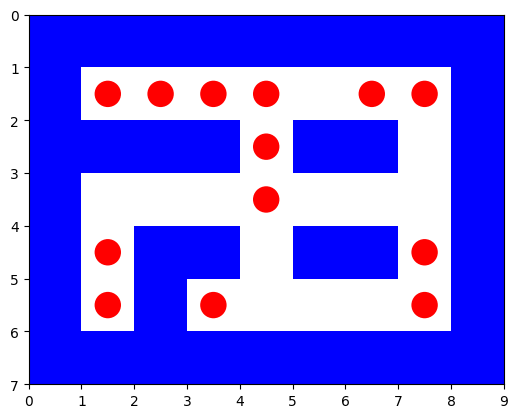

 
astar_search:
Solution path is  [(3, 4), (2, 4), (1, 4), (1, 3), (1, 2), (1, 1)] 

Number of nodes expanded 19 

Maximum size of finge 5 

Maximum tree depth searched: 5
 
 
 path to reach from  (1, 1) to  (1, 2)  is
 
[(1, 1), (1, 2)]
 
%%%%%%%%%
%.... ..%
%%%%.%% %
%   .   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


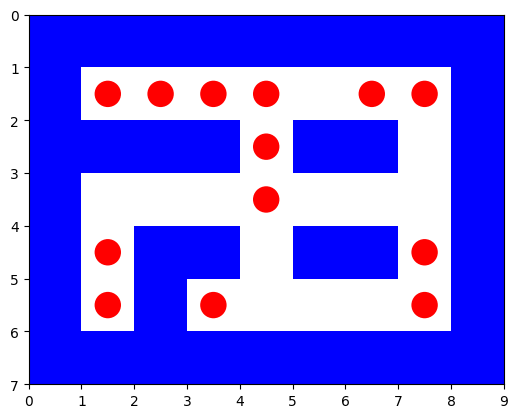

 
astar_search:
Solution path is  [(1, 1), (1, 2)] 

Number of nodes expanded 1 

Maximum size of finge 1 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 2) to  (1, 6)  is
 
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%   .   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


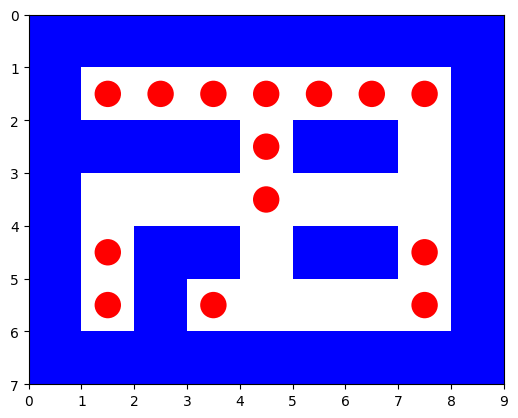

 
astar_search:
Solution path is  [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)] 

Number of nodes expanded 9 

Maximum size of finge 3 

Maximum tree depth searched: 4
 
 
 path to reach from  (1, 6) to  (1, 7)  is
 
[(1, 6), (1, 7)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%   .   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


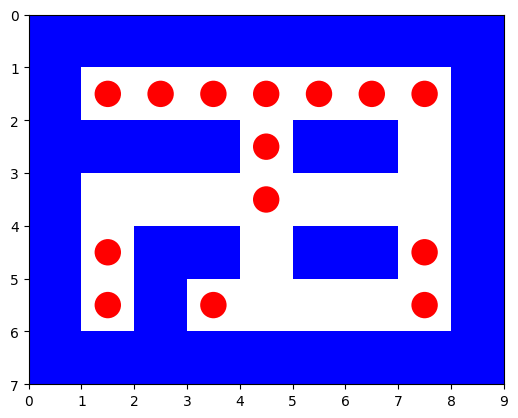

 
astar_search:
Solution path is  [(1, 6), (1, 7)] 

Number of nodes expanded 2 

Maximum size of finge 2 

Maximum tree depth searched: 1
 
 
 path to reach from  (1, 7) to  (2, 4)  is
 
[(1, 7), (1, 6), (1, 5), (1, 4), (2, 4)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%   .   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


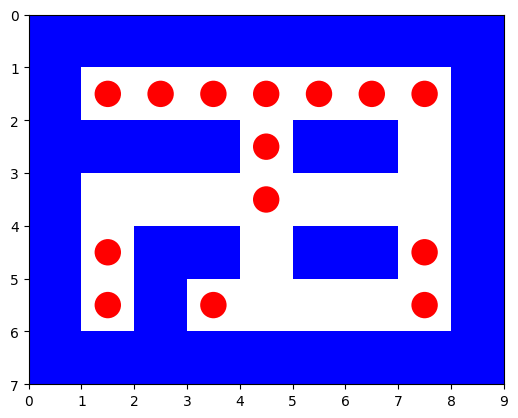

 
astar_search:
Solution path is  [(1, 7), (1, 6), (1, 5), (1, 4), (2, 4)] 

Number of nodes expanded 11 

Maximum size of finge 3 

Maximum tree depth searched: 4
 
 
 path to reach from  (2, 4) to  (4, 1)  is
 
[(2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%....   %
%.%% %%.%
%.%.   .%
%%%%%%%%%


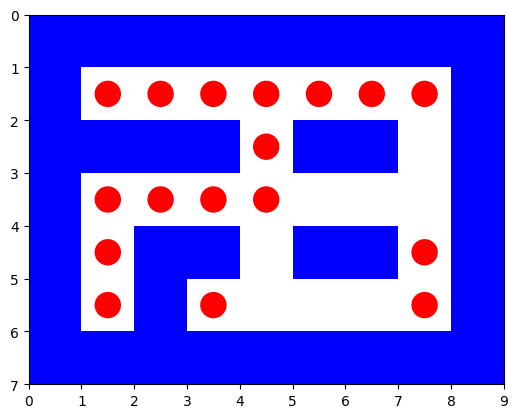

 
astar_search:
Solution path is  [(2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1)] 

Number of nodes expanded 14 

Maximum size of finge 4 

Maximum tree depth searched: 5
 
 
 path to reach from  (4, 1) to  (4, 7)  is
 
[(4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%.......%
%.%% %%.%
%.%.   .%
%%%%%%%%%


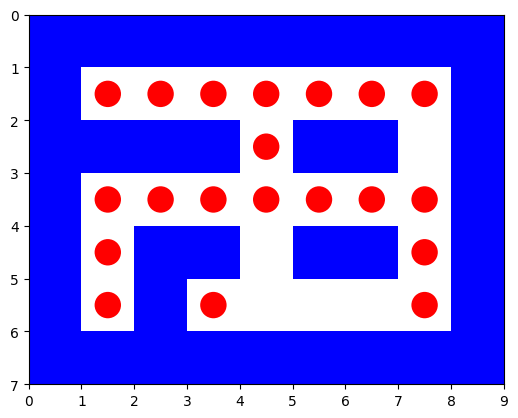

 
astar_search:
Solution path is  [(4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7)] 

Number of nodes expanded 22 

Maximum size of finge 4 

Maximum tree depth searched: 8
 
 
 path to reach from  (4, 7) to  (5, 1)  is
 
[(4, 7), (3, 7), (3, 6), (3, 5), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%.......%
%.%% %%.%
%.%.   .%
%%%%%%%%%


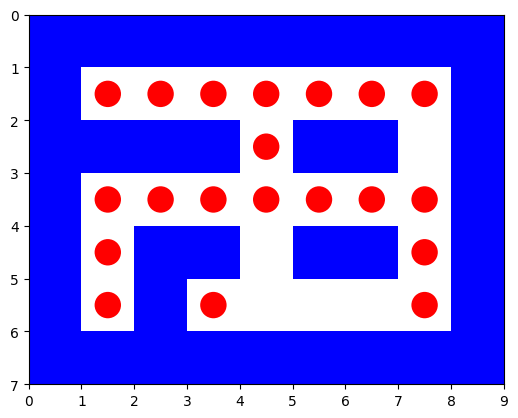

 
astar_search:
Solution path is  [(4, 7), (3, 7), (3, 6), (3, 5), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1)] 

Number of nodes expanded 33 

Maximum size of finge 4 

Maximum tree depth searched: 9
 
 
 path to reach from  (5, 1) to  (5, 3)  is
 
[(5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4), (5, 4), (5, 3)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%.......%
%.%%.%%.%
%.%..  .%
%%%%%%%%%


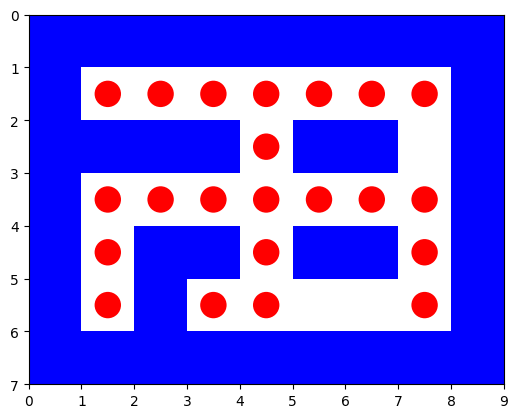

 
astar_search:
Solution path is  [(5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4), (5, 4), (5, 3)] 

Number of nodes expanded 18 

Maximum size of finge 4 

Maximum tree depth searched: 8
 
 
 path to reach from  (5, 3) to  (5, 7)  is
 
[(5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
 
%%%%%%%%%
%.......%
%%%%.%% %
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%


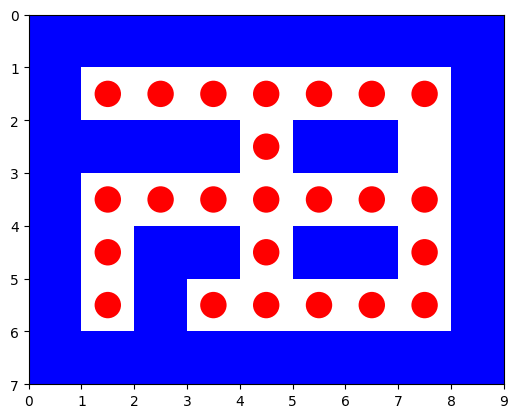

 
astar_search:
Solution path is  [(5, 3), (5, 4), (5, 5), (5, 6), (5, 7)] 

Number of nodes expanded 8 

Maximum size of finge 2 

Maximum tree depth searched: 4
%%%%%%%%%
%.......%
%%%%.%% %
%.......%
%.%%.%%.%
%.%.....%
%%%%%%%%%
overall path


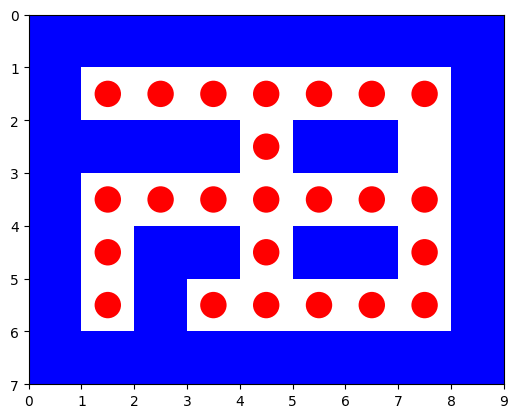

final path from starting point to the last goal [(3, 4), (2, 4), (1, 4), (1, 3), (1, 2), (1, 1), (1, 1), (1, 2), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 6), (1, 7), (1, 7), (1, 6), (1, 5), (1, 4), (2, 4), (2, 4), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (4, 7), (3, 7), (3, 6), (3, 5), (3, 4), (3, 3), (3, 2), (3, 1), (4, 1), (5, 1), (5, 1), (4, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4), (5, 4), (5, 3), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]


In [67]:

with open("/content/tinySearch.lay", "r") as tinySearchfile:
    maze=list(tinySearchfile)

start = None
goal = None
mutiple_goals={}
k=0
Final_path=[]
for i in range(len(maze)):
    maze[i] = maze[i].replace("\n", "")
    for j in range(len(maze[i])):
        if maze[i][j] == 'P':
            start = (i, j)
        elif maze[i][j] == '.':
            goal= (i, j)
            mutiple_goals[k]=goal
            k=k+1
print(start,mutiple_goals)
maze_plot(maze)
for a in range(k):
  problem = Maze_Problem(maze, start, mutiple_goals[a])
  solution_node = astar_search(problem)
  print(' ')


  if solution_node.node == failure:
    print("No solution")
  else:
    astar_solution_path = path_states(solution_node.node)
    Final_path+=astar_solution_path
    li=[]
    print(' ')
    print(" path to reach from ",start,"to ",mutiple_goals[a]," is")
    print(' ')
    print(astar_solution_path )
    print(' ')
    for i in range(len(maze)):
        maze_store = ''
        for j in range(len(maze[i])):
            if (i, j) in astar_solution_path :
                maze_store += '.'
                maze[i] = list(maze[i])
                maze[i][j]= '.'
            else:
                maze_store += maze[i][j]
        print(maze_store)
        li.append(maze_store)
  maze_plot(li)
  start=mutiple_goals[a]
  maze=maze
  print(' ')
  report([astar_search], [problem],astar_solution_path)
li=[]
for i in range(len(maze)):
  maze_store = ''
  for j in range(len(maze[i])):
    if (i, j) in Final_path :
      maze_store += '.'
    else:
      maze_store += maze[i][j]
  print(maze_store)
  li.append(maze_store)
print("overall path")
maze_plot(li)
print("final path from starting point to the last goal",Final_path)
